<a href="https://colab.research.google.com/github/angeruzzi/home-credit-default-risk/blob/main/notebooks/02_application_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Credit Default Risk: Análise Exploratória das Aplicações

## Introdução

Este notebook realiza a análise exploratória das tabelas
`application_train` e `application_test` da competição Home Credit Default
Risk.

A tabela `application_train` contém as solicitações utilizadas para o
desenvolvimento dos modelos e inclui a variável-alvo `TARGET`. A tabela
`application_test` possui as mesmas variáveis explicativas, mas não contém o
evento observado, pois foi disponibilizada originalmente para avaliação das
submissões da competição.

A análise terá dois focos complementares:

1. compreender a qualidade, distribuição e comportamento das variáveis na
   população de desenvolvimento;
2. comparar as populações de `application_train` e `application_test` para
   identificar diferenças relevantes de distribuição.

Serão investigados missing values, variáveis categóricas, distribuições
numéricas, outliers, anomalias, relações com `TARGET` e possíveis fontes de
data leakage.

Nesta etapa, os dados originais não serão alterados. Os tratamentos serão
definidos a partir das evidências encontradas e implementados posteriormente no
notebook de engenharia de variáveis.

### 1. Objetivos

Os objetivos deste notebook são:

- validar a disponibilidade dos dados e carregar as tabelas de aplicação;
- classificar as variáveis por tipo e finalidade;
- analisar o padrão e a concentração de missing values;
- investigar a distribuição e a cardinalidade das variáveis categóricas;
- avaliar distribuições, assimetria e valores extremos das variáveis numéricas;
- identificar valores sentinela e inconsistências semânticas;
- analisar relações univariadas entre as variáveis e `TARGET`;
- comparar características das populações de desenvolvimento e da competição;
- identificar variáveis com risco potencial de data leakage;
- registrar decisões para a etapa de engenharia de variáveis.

A análise será orientada não apenas pela associação estatística com o evento,
mas também pela interpretação de negócio, disponibilidade temporal,
estabilidade e possibilidade de utilização no momento da solicitação.

## Configuração do Ambiente

A configuração compartilhada de diretórios e cache está centralizada no arquivo
`utils.py`.

O notebook manterá apenas o código mínimo necessário para obter o repositório,
instalar as dependências e importar as funções auxiliares.

In [1]:
# initializing
import os
import sys
import subprocess
from pathlib import Path
import importlib

IN_COLAB = "google.colab" in sys.modules

REPOSITORY_URL = (
    "https://github.com/angeruzzi/home-credit-default-risk.git"
)

if IN_COLAB:
    PROJECT_ROOT = Path(
        "/content/home-credit-default-risk"
    )

    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPOSITORY_URL,
                str(PROJECT_ROOT),
            ],
            check=True,
        )

    else:
        subprocess.run(
            [
                "git",
                "-C",
                str(PROJECT_ROOT),
                "pull",
                "--ff-only",
                "origin",
                "main",
            ],
            check=True,
        )

else:
    current_directory = Path.cwd().resolve()

    PROJECT_ROOT = (
        current_directory.parent
        if current_directory.name == "notebooks"
        else current_directory
    )

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

# Instalação das dependências
REQUIREMENTS_PATH = (
    PROJECT_ROOT / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {REQUIREMENTS_PATH}"
    )

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    check=True,
)

print("Dependências instaladas com sucesso.")


import utils
importlib.reload(utils)

from utils import setup_project

paths = setup_project(
    use_google_drive_cache=True,
)


Raiz do projeto: /content/home-credit-default-risk
Dependências instaladas com sucesso.
Mounted at /content/drive
Ambiente Colab: True
Modo de armazenamento: Google Drive
Raiz do projeto: /content/home-credit-default-risk
Dados: /content/drive/MyDrive/home-credit-default-risk/data
Artefatos: /content/drive/MyDrive/home-credit-default-risk/artifacts
Relatórios: /content/home-credit-default-risk/reports


In [2]:
# Imports do notebook
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
import scipy
from scipy import stats

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(
    style="whitegrid",
    palette="deep",
)

RANDOM_STATE = 42

In [3]:
# Registro das versões
environment_versions = pd.DataFrame(
    [
        {
            "componente": "Python",
            "versao": platform.python_version(),
        },
        {
            "componente": "NumPy",
            "versao": np.__version__,
        },
        {
            "componente": "Pandas",
            "versao": pd.__version__,
        },
        {
            "componente": "Matplotlib",
            "versao": plt.matplotlib.__version__,
        },
        {
            "componente": "Seaborn",
            "versao": sns.__version__,
        },
        {
            "componente": "SciPy",
            "versao": scipy.__version__,
        },
    ]
)

display(environment_versions)

,componente,versao
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,Matplotlib,3.10.0
4,Seaborn,0.13.2
5,SciPy,1.16.3


## Carregamento e Validação dos Dados

As tabelas `application_train` e `application_test` serão carregadas a partir do
cache configurado.

Embora essas validações também tenham sido realizadas no primeiro notebook,
elas são repetidas de forma resumida para garantir que este notebook possa ser
executado independentemente.

In [4]:
APPLICATION_TRAIN_PATH = (
    paths.data_raw / "application_train.csv"
)

APPLICATION_TEST_PATH = (
    paths.data_raw / "application_test.csv"
)

required_files = [
    APPLICATION_TRAIN_PATH,
    APPLICATION_TEST_PATH,
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Arquivos necessários não encontrados:\n"
        + "\n".join(missing_files)
        + "\nExecute primeiro o notebook 01."
    )

application_train = pd.read_csv(
    APPLICATION_TRAIN_PATH,
    low_memory=False,
)

application_test = pd.read_csv(
    APPLICATION_TEST_PATH,
    low_memory=False,
)

print(
    "application_train: "
    f"{application_train.shape[0]:,} registros e "
    f"{application_train.shape[1]} colunas"
)

print(
    "application_test: "
    f"{application_test.shape[0]:,} registros e "
    f"{application_test.shape[1]} colunas"
)

application_train: 307,511 registros e 122 colunas
application_test: 48,744 registros e 121 colunas


In [5]:
# Validações mínimas
assert "SK_ID_CURR" in application_train.columns
assert "SK_ID_CURR" in application_test.columns

assert "TARGET" in application_train.columns
assert "TARGET" not in application_test.columns

assert application_train["SK_ID_CURR"].is_unique
assert application_test["SK_ID_CURR"].is_unique

assert application_train["SK_ID_CURR"].notna().all()
assert application_test["SK_ID_CURR"].notna().all()

assert set(application_train["TARGET"].unique()) == {0, 1}
assert application_train["TARGET"].notna().all()

train_predictor_columns = set(
    application_train.columns
) - {"TARGET"}

test_predictor_columns = set(
    application_test.columns
)

assert train_predictor_columns == test_predictor_columns

print("Validações concluídas com sucesso.")

Validações concluídas com sucesso.


In [6]:
# Primeiras observações
display(application_train.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [7]:
# Amostra transposta
display(
    application_train
    .head(3)
    .T
    .rename(
        columns={
            0: "solicitacao_1",
            1: "solicitacao_2",
            2: "solicitacao_3",
        }
    )
)

,solicitacao_1,solicitacao_2,solicitacao_3
SK_ID_CURR,100002,100003,100004
TARGET,1,0,0
NAME_CONTRACT_TYPE,Cash loans,Cash loans,Revolving loans
CODE_GENDER,M,F,M
FLAG_OWN_CAR,N,N,Y
...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_MON,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.0,0.0


## Análise de Missing Values

Valores ausentes podem ter origens distintas:

- informação não coletada;
- informação não disponível em uma fonte externa;
- característica não aplicável ao cliente;
- falha operacional;
- ausência potencialmente informativa sobre o risco.

Por isso, o percentual de missing não será utilizado isoladamente como critério
de exclusão. Também serão consideradas a interpretação da variável, sua relação
com `TARGET` e a consistência entre as populações.

In [8]:
# Perfil de missing
def build_missing_profile(
    dataframe: pd.DataFrame,
    dataset_name: str,
    excluded_columns: list[str] | None = None,
) -> pd.DataFrame:
    """
    Calcula quantidade e percentual de missing por variável.
    """
    excluded_columns = excluded_columns or []

    selected_columns = [
        column
        for column in dataframe.columns
        if column not in excluded_columns
    ]

    missing_count = (
        dataframe[selected_columns]
        .isna()
        .sum()
    )

    missing_percentage = (
        missing_count
        / len(dataframe)
        * 100
    )

    profile = pd.DataFrame(
        {
            "variavel": selected_columns,
            f"missing_{dataset_name}_quantidade": (
                missing_count.values
            ),
            f"missing_{dataset_name}_percentual": (
                missing_percentage.values
            ),
        }
    )

    return profile

In [9]:
train_missing_profile = build_missing_profile(
    application_train,
    dataset_name="train",
    excluded_columns=["TARGET"],
)

test_missing_profile = build_missing_profile(
    application_test,
    dataset_name="test",
)

missing_comparison = (
    train_missing_profile
    .merge(
        test_missing_profile,
        how="outer",
        on="variavel",
        validate="one_to_one",
    )
)

missing_comparison[
    "diferenca_absoluta_percentual"
] = (
    missing_comparison[
        "missing_train_percentual"
    ]
    - missing_comparison[
        "missing_test_percentual"
    ]
).abs()

missing_comparison = (
    missing_comparison
    .sort_values(
        "missing_train_percentual",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [10]:
# Resumo geral
missing_overview = pd.DataFrame(
    [
        {
            "populacao": "application_train",
            "variaveis": len(train_predictor_columns),
            "com_missing": (
                missing_comparison[
                    "missing_train_percentual"
                ] > 0
            ).sum(),
            "acima_30_percent": (
                missing_comparison[
                    "missing_train_percentual"
                ] > 30
            ).sum(),
            "acima_50_percent": (
                missing_comparison[
                    "missing_train_percentual"
                ] > 50
            ).sum(),
            "maior_percentual": (
                missing_comparison[
                    "missing_train_percentual"
                ].max()
            ),
        },
        {
            "populacao": "application_test",
            "variaveis": len(test_predictor_columns),
            "com_missing": (
                missing_comparison[
                    "missing_test_percentual"
                ] > 0
            ).sum(),
            "acima_30_percent": (
                missing_comparison[
                    "missing_test_percentual"
                ] > 30
            ).sum(),
            "acima_50_percent": (
                missing_comparison[
                    "missing_test_percentual"
                ] > 50
            ).sum(),
            "maior_percentual": (
                missing_comparison[
                    "missing_test_percentual"
                ].max()
            ),
        },
    ]
)

display(
    missing_overview.style.format(
        {
            "maior_percentual": "{:.2f}%",
        }
    )
)

,populacao,variaveis,com_missing,acima_30_percent,acima_50_percent,maior_percentual
0,application_train,121,67,50,41,69.87%
1,application_test,121,64,50,29,68.72%


In [11]:
# Variáveis com maior missing
display(
    missing_comparison[
        [
            "variavel",
            "missing_train_quantidade",
            "missing_train_percentual",
            "missing_test_percentual",
            "diferenca_absoluta_percentual",
        ]
    ]
    .head(30)
    .style.format(
        {
            "missing_train_quantidade": "{:,.0f}",
            "missing_train_percentual": "{:.2f}%",
            "missing_test_percentual": "{:.2f}%",
            "diferenca_absoluta_percentual": "{:.2f} p.p.",
        }
    )
)

,variavel,missing_train_quantidade,missing_train_percentual,missing_test_percentual,diferenca_absoluta_percentual
0,COMMONAREA_AVG,"214,865",69.87%,68.72%,1.16 p.p.
1,COMMONAREA_MODE,"214,865",69.87%,68.72%,1.16 p.p.
2,COMMONAREA_MEDI,"214,865",69.87%,68.72%,1.16 p.p.
3,NONLIVINGAPARTMENTS_AVG,"213,514",69.43%,68.41%,1.02 p.p.
4,NONLIVINGAPARTMENTS_MODE,"213,514",69.43%,68.41%,1.02 p.p.
5,NONLIVINGAPARTMENTS_MEDI,"213,514",69.43%,68.41%,1.02 p.p.
6,FONDKAPREMONT_MODE,"210,295",68.39%,67.28%,1.10 p.p.
7,LIVINGAPARTMENTS_AVG,"210,199",68.35%,67.25%,1.11 p.p.
8,LIVINGAPARTMENTS_MODE,"210,199",68.35%,67.25%,1.11 p.p.
9,LIVINGAPARTMENTS_MEDI,"210,199",68.35%,67.25%,1.11 p.p.


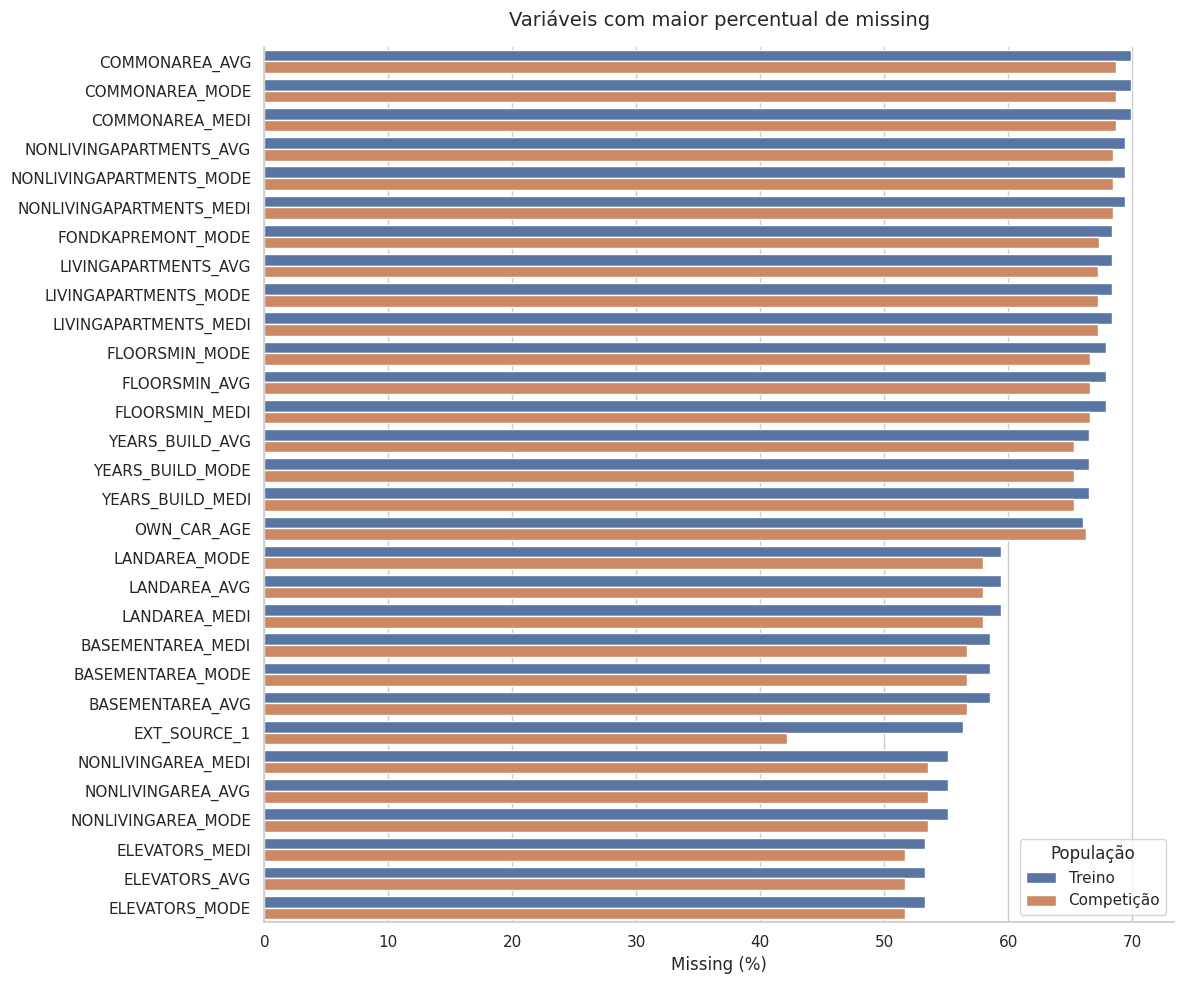

In [12]:
# Visualização das 30 maiores taxas
top_missing_variables = (
    missing_comparison
    .head(30)
    .copy()
)

missing_plot_data = (
    top_missing_variables[
        [
            "variavel",
            "missing_train_percentual",
            "missing_test_percentual",
        ]
    ]
    .melt(
        id_vars="variavel",
        var_name="populacao",
        value_name="percentual",
    )
)

missing_plot_data["populacao"] = (
    missing_plot_data["populacao"]
    .map(
        {
            "missing_train_percentual": "Treino",
            "missing_test_percentual": "Competição",
        }
    )
)

fig, ax = plt.subplots(
    figsize=(12, 10)
)

sns.barplot(
    data=missing_plot_data,
    y="variavel",
    x="percentual",
    hue="populacao",
    ax=ax,
)

ax.set_title(
    "Variáveis com maior percentual de missing",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Missing (%)")
ax.set_ylabel("")
ax.legend(title="População")

sns.despine()
plt.tight_layout()

MISSING_VALUES_FIGURE_PATH = (
    paths.figures / "application_missing_values.png"
)

fig.savefig(
    MISSING_VALUES_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [13]:
# Maiores diferenças entre as populações
missing_population_differences = (
    missing_comparison
    .sort_values(
        "diferenca_absoluta_percentual",
        ascending=False,
    )
    [
        [
            "variavel",
            "missing_train_percentual",
            "missing_test_percentual",
            "diferenca_absoluta_percentual",
        ]
    ]
    .head(20)
)

display(
    missing_population_differences.style.format(
        {
            "missing_train_percentual": "{:.2f}%",
            "missing_test_percentual": "{:.2f}%",
            "diferenca_absoluta_percentual": "{:.2f} p.p.",
        }
    )
)

,variavel,missing_train_percentual,missing_test_percentual,diferenca_absoluta_percentual
23,EXT_SOURCE_1,56.38%,42.12%,14.26 p.p.
50,EXT_SOURCE_3,19.83%,17.78%,2.04 p.p.
36,ENTRANCES_AVG,50.35%,48.37%,1.98 p.p.
35,ENTRANCES_MODE,50.35%,48.37%,1.98 p.p.
34,ENTRANCES_MEDI,50.35%,48.37%,1.98 p.p.
43,FLOORSMAX_AVG,49.76%,47.84%,1.92 p.p.
41,FLOORSMAX_MEDI,49.76%,47.84%,1.92 p.p.
42,FLOORSMAX_MODE,49.76%,47.84%,1.92 p.p.
45,YEARS_BEGINEXPLUATATION_MODE,48.78%,46.89%,1.89 p.p.
44,YEARS_BEGINEXPLUATATION_MEDI,48.78%,46.89%,1.89 p.p.


### Missing como Potencial Sinal de Risco

Em dados de crédito, a ausência de uma informação pode carregar sinal
preditivo. Por exemplo, um dado externo pode estar indisponível para clientes
com pouco histórico, enquanto determinadas informações patrimoniais podem não
se aplicar a todos os solicitantes.

Para cada variável com missing, será comparada a taxa observada de dificuldade
de pagamento entre:

- clientes com informação ausente;
- clientes com informação presente.

Essa análise é exploratória. Diferenças de taxa não representam causalidade e
também podem refletir características correlacionadas da população.

In [14]:
# Construção da análise
variables_with_missing = (
    missing_comparison.loc[
        missing_comparison[
            "missing_train_quantidade"
        ] > 0,
        "variavel",
    ]
    .tolist()
)

missing_target_records = []

for variable in variables_with_missing:
    missing_mask = application_train[variable].isna()
    present_mask = ~missing_mask

    missing_count = int(missing_mask.sum())
    present_count = int(present_mask.sum())

    event_rate_missing = (
        application_train.loc[
            missing_mask,
            "TARGET",
        ].mean()
    )

    event_rate_present = (
        application_train.loc[
            present_mask,
            "TARGET",
        ].mean()
    )

    difference_percentage_points = (
        event_rate_missing
        - event_rate_present
    ) * 100

    event_rate_ratio = (
        event_rate_missing
        / event_rate_present
        if event_rate_present > 0
        else np.nan
    )

    missing_target_records.append(
        {
            "variavel": variable,
            "missing_quantidade": missing_count,
            "missing_percentual": (
                missing_count
                / len(application_train)
                * 100
            ),
            "presentes_quantidade": present_count,
            "taxa_evento_missing": (
                event_rate_missing * 100
            ),
            "taxa_evento_presente": (
                event_rate_present * 100
            ),
            "diferenca_taxa_pontos_percentuais": (
                difference_percentage_points
            ),
            "razao_taxas": event_rate_ratio,
        }
    )

missing_target_analysis = pd.DataFrame(
    missing_target_records
)

missing_target_analysis[
    "diferenca_absoluta_pontos_percentuais"
] = (
    missing_target_analysis[
        "diferenca_taxa_pontos_percentuais"
    ].abs()
)

In [15]:
# Aplicação de suporte mínimo

# Diferenças baseadas em poucos registros podem ser instáveis.
# Para a ordenação principal, considere apenas variáveis com pelo menos 1% da população em ambos os grupos:

MINIMUM_GROUP_SHARE = 0.01
MINIMUM_GROUP_SIZE = int(
    len(application_train)
    * MINIMUM_GROUP_SHARE
)

missing_target_supported = (
    missing_target_analysis[
        (
            missing_target_analysis[
                "missing_quantidade"
            ] >= MINIMUM_GROUP_SIZE
        )
        & (
            missing_target_analysis[
                "presentes_quantidade"
            ] >= MINIMUM_GROUP_SIZE
        )
    ]
    .sort_values(
        "diferenca_absoluta_pontos_percentuais",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    f"Suporte mínimo por grupo: "
    f"{MINIMUM_GROUP_SIZE:,} registros"
)

print(
    "Variáveis elegíveis para comparação: "
    f"{len(missing_target_supported)}"
)

Suporte mínimo por grupo: 3,075 registros
Variáveis elegíveis para comparação: 57


In [16]:
# Principais diferenças
display(
    missing_target_supported[
        [
            "variavel",
            "missing_quantidade",
            "missing_percentual",
            "taxa_evento_missing",
            "taxa_evento_presente",
            "diferenca_taxa_pontos_percentuais",
            "razao_taxas",
        ]
    ]
    .head(20)
    .style.format(
        {
            "missing_quantidade": "{:,.0f}",
            "missing_percentual": "{:.2f}%",
            "taxa_evento_missing": "{:.2f}%",
            "taxa_evento_presente": "{:.2f}%",
            "diferenca_taxa_pontos_percentuais": (
                "{:+.2f} p.p."
            ),
            "razao_taxas": "{:.2f}x",
        }
    )
)

,variavel,missing_quantidade,missing_percentual,taxa_evento_missing,taxa_evento_presente,diferenca_taxa_pontos_percentuais,razao_taxas
0,AMT_REQ_CREDIT_BUREAU_WEEK,"41,519",13.50%,10.34%,7.72%,+2.62 p.p.,1.34x
1,AMT_REQ_CREDIT_BUREAU_QRT,"41,519",13.50%,10.34%,7.72%,+2.62 p.p.,1.34x
2,AMT_REQ_CREDIT_BUREAU_DAY,"41,519",13.50%,10.34%,7.72%,+2.62 p.p.,1.34x
3,AMT_REQ_CREDIT_BUREAU_HOUR,"41,519",13.50%,10.34%,7.72%,+2.62 p.p.,1.34x
4,AMT_REQ_CREDIT_BUREAU_MON,"41,519",13.50%,10.34%,7.72%,+2.62 p.p.,1.34x
5,AMT_REQ_CREDIT_BUREAU_YEAR,"41,519",13.50%,10.34%,7.72%,+2.62 p.p.,1.34x
6,OCCUPATION_TYPE,"96,391",31.35%,6.51%,8.79%,-2.27 p.p.,0.74x
7,EMERGENCYSTATE_MODE,"145,755",47.40%,9.26%,7.00%,+2.26 p.p.,1.32x
8,TOTALAREA_MODE,"148,431",48.27%,9.23%,6.99%,+2.24 p.p.,1.32x
9,ENTRANCES_AVG,"154,828",50.35%,9.18%,6.95%,+2.23 p.p.,1.32x


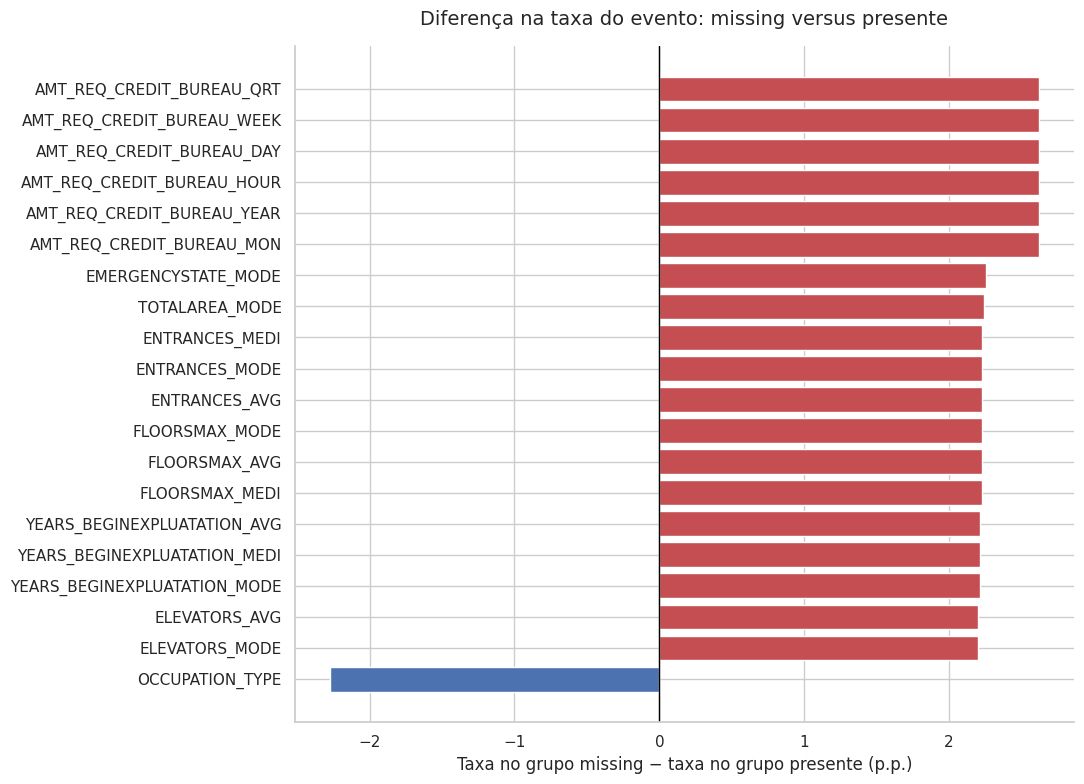

In [17]:
# Visualização
top_missing_signals = (
    missing_target_supported
    .head(20)
    .sort_values(
        "diferenca_taxa_pontos_percentuais"
    )
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

colors = np.where(
    top_missing_signals[
        "diferenca_taxa_pontos_percentuais"
    ] >= 0,
    "#C44E52",
    "#4C72B0",
)

ax.barh(
    top_missing_signals["variavel"],
    top_missing_signals[
        "diferenca_taxa_pontos_percentuais"
    ],
    color=colors,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Diferença na taxa do evento: missing versus presente",
    fontsize=14,
    pad=15,
)

ax.set_xlabel(
    "Taxa no grupo missing − taxa no grupo presente (p.p.)"
)

ax.set_ylabel("")

sns.despine()
plt.tight_layout()

MISSING_TARGET_FIGURE_PATH = (
    paths.figures
    / "missing_target_association.png"
)

fig.savefig(
    MISSING_TARGET_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [18]:
# Persistência dos resultados
MISSING_TARGET_TABLE_PATH = (
    paths.tables
    / "missing_target_association.csv"
)

missing_target_analysis.to_csv(
    MISSING_TARGET_TABLE_PATH,
    index=False,
)

print(
    "Tabela salva em: "
    f"{MISSING_TARGET_TABLE_PATH}"
)

Tabela salva em: /content/home-credit-default-risk/reports/tables/missing_target_association.csv


## Análise das Variáveis Categóricas

As variáveis categóricas serão avaliadas quanto a:

- cardinalidade;
- valores ausentes;
- categorias raras;
- códigos especiais, como `XNA`, `XAP` e `Unknown`;
- categorias existentes somente em uma das populações;
- associação entre as categorias e a taxa observada do evento.

Categorias especiais não serão interpretadas automaticamente como missing.
Primeiro será necessário compreender seu significado e sua frequência em cada
variável.

In [19]:
# Identificação das variáveis categóricas
categorical_columns = (
    application_train
    .select_dtypes(
        include=[
            "object",
            "category",
            "string",
        ]
    )
    .columns
    .tolist()
)

print(
    f"Quantidade de variáveis categóricas: "
    f"{len(categorical_columns)}"
)

print("\nVariáveis:")
for column in categorical_columns:
    print(f"  - {column}")

Quantidade de variáveis categóricas: 16

Variáveis:
  - NAME_CONTRACT_TYPE
  - CODE_GENDER
  - FLAG_OWN_CAR
  - FLAG_OWN_REALTY
  - NAME_TYPE_SUITE
  - NAME_INCOME_TYPE
  - NAME_EDUCATION_TYPE
  - NAME_FAMILY_STATUS
  - NAME_HOUSING_TYPE
  - OCCUPATION_TYPE
  - WEEKDAY_APPR_PROCESS_START
  - ORGANIZATION_TYPE
  - FONDKAPREMONT_MODE
  - HOUSETYPE_MODE
  - WALLSMATERIAL_MODE
  - EMERGENCYSTATE_MODE


In [20]:
# Construção do perfil categórico
RARE_CATEGORY_THRESHOLD = 0.005

SPECIAL_CATEGORY_VALUES = {
    "XNA",
    "XAP",
    "Unknown",
    "UNKNOWN",
    "Other",
}

categorical_profile_records = []

for variable in categorical_columns:
    train_series = application_train[variable]
    test_series = application_test[variable]

    train_categories = set(
        train_series.dropna().unique()
    )

    test_categories = set(
        test_series.dropna().unique()
    )

    train_frequency = (
        train_series
        .value_counts(
            normalize=True,
            dropna=False,
        )
    )

    rare_categories_count = int(
        (
            train_frequency
            < RARE_CATEGORY_THRESHOLD
        ).sum()
    )

    special_values_found = sorted(
        train_categories.intersection(
            SPECIAL_CATEGORY_VALUES
        )
    )

    categorical_profile_records.append(
        {
            "variavel": variable,
            "categorias_train": (
                train_series.nunique(dropna=True)
            ),
            "categorias_test": (
                test_series.nunique(dropna=True)
            ),
            "missing_train_percentual": (
                train_series.isna().mean() * 100
            ),
            "missing_test_percentual": (
                test_series.isna().mean() * 100
            ),
            "categorias_raras_train": (
                rare_categories_count
            ),
            "categorias_apenas_train": (
                len(
                    train_categories
                    - test_categories
                )
            ),
            "categorias_apenas_test": (
                len(
                    test_categories
                    - train_categories
                )
            ),
            "valores_especiais": (
                ", ".join(special_values_found)
                if special_values_found
                else ""
            ),
        }
    )

categorical_profile = (
    pd.DataFrame(categorical_profile_records)
    .sort_values(
        "categorias_train",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    categorical_profile.style.format(
        {
            "missing_train_percentual": "{:.2f}%",
            "missing_test_percentual": "{:.2f}%",
        }
    )
)

,variavel,categorias_train,categorias_test,missing_train_percentual,missing_test_percentual,categorias_raras_train,categorias_apenas_train,categorias_apenas_test,valores_especiais
0,ORGANIZATION_TYPE,58,58,0.00%,0.00%,29,0,0,"Other, XNA"
1,OCCUPATION_TYPE,18,18,31.35%,32.01%,5,0,0,
2,NAME_INCOME_TYPE,8,7,0.00%,0.00%,4,1,0,
3,NAME_TYPE_SUITE,7,7,0.42%,1.87%,3,0,0,
4,WALLSMATERIAL_MODE,7,7,50.84%,49.02%,0,0,0,
5,WEEKDAY_APPR_PROCESS_START,7,7,0.00%,0.00%,0,0,0,
6,NAME_FAMILY_STATUS,6,5,0.00%,0.00%,1,1,0,Unknown
7,NAME_HOUSING_TYPE,6,6,0.00%,0.00%,1,0,0,
8,NAME_EDUCATION_TYPE,5,5,0.00%,0.00%,1,0,0,
9,FONDKAPREMONT_MODE,4,4,68.39%,67.28%,0,0,0,


In [21]:
# Categorias presentes somente em uma população
# Essa verificação é importante porque métodos como One-Hot Encoding precisam tratar categorias desconhecidas no momento da transformação.
population_category_differences = []

for variable in categorical_columns:
    train_categories = set(
        application_train[variable]
        .dropna()
        .unique()
    )

    test_categories = set(
        application_test[variable]
        .dropna()
        .unique()
    )

    only_train = sorted(
        train_categories - test_categories,
        key=str,
    )

    only_test = sorted(
        test_categories - train_categories,
        key=str,
    )

    if only_train or only_test:
        population_category_differences.append(
            {
                "variavel": variable,
                "apenas_train": only_train,
                "apenas_test": only_test,
            }
        )

category_difference_table = pd.DataFrame(
    population_category_differences
)

if category_difference_table.empty:
    print(
        "Não foram encontradas categorias exclusivas "
        "entre as populações."
    )
else:
    display(category_difference_table)

,variavel,apenas_train,apenas_test
0,CODE_GENDER,[XNA],[]
1,NAME_INCOME_TYPE,[Maternity leave],[]
2,NAME_FAMILY_STATUS,[Unknown],[]


In [22]:
# Identificação das categorias raras
rare_category_records = []

for variable in categorical_columns:
    category_counts = (
        application_train[variable]
        .fillna("<MISSING>")
        .value_counts(
            dropna=False,
        )
    )

    category_percentages = (
        category_counts
        / len(application_train)
        * 100
    )

    for category, percentage in (
        category_percentages.items()
    ):
        if percentage < (
            RARE_CATEGORY_THRESHOLD * 100
        ):
            rare_category_records.append(
                {
                    "variavel": variable,
                    "categoria": category,
                    "quantidade": (
                        category_counts.loc[category]
                    ),
                    "percentual": percentage,
                }
            )

rare_categories = (
    pd.DataFrame(rare_category_records)
    .sort_values(
        [
            "variavel",
            "percentual",
        ]
    )
    .reset_index(drop=True)
)

display(
    rare_categories.style.format(
        {
            "quantidade": "{:,.0f}",
            "percentual": "{:.4f}%",
        }
    )
)

,variavel,categoria,quantidade,percentual
0,CODE_GENDER,XNA,4,0.0013%
1,HOUSETYPE_MODE,terraced house,"1,212",0.3941%
2,HOUSETYPE_MODE,specific housing,"1,499",0.4875%
3,NAME_EDUCATION_TYPE,Academic degree,164,0.0533%
4,NAME_FAMILY_STATUS,Unknown,2,0.0007%
5,NAME_HOUSING_TYPE,Co-op apartment,"1,122",0.3649%
6,NAME_INCOME_TYPE,Maternity leave,5,0.0016%
7,NAME_INCOME_TYPE,Businessman,10,0.0033%
8,NAME_INCOME_TYPE,Student,18,0.0059%
9,NAME_INCOME_TYPE,Unemployed,22,0.0072%


In [23]:
# Valores especiais
special_category_records = []

for variable in categorical_columns:
    value_counts = (
        application_train[variable]
        .value_counts(
            dropna=False,
        )
    )

    for special_value in SPECIAL_CATEGORY_VALUES:
        if special_value in value_counts.index:
            count = int(
                value_counts.loc[special_value]
            )

            special_category_records.append(
                {
                    "variavel": variable,
                    "valor_especial": special_value,
                    "quantidade": count,
                    "percentual": (
                        count
                        / len(application_train)
                        * 100
                    ),
                }
            )

special_categories = (
    pd.DataFrame(special_category_records)
    .sort_values(
        "quantidade",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    special_categories.style.format(
        {
            "quantidade": "{:,.0f}",
            "percentual": "{:.4f}%",
        }
    )
)

,variavel,valor_especial,quantidade,percentual
0,ORGANIZATION_TYPE,XNA,"55,374",18.0072%
1,ORGANIZATION_TYPE,Other,"16,683",5.4252%
2,CODE_GENDER,XNA,4,0.0013%
3,NAME_FAMILY_STATUS,Unknown,2,0.0007%


In [24]:
# Persistência do perfil
CATEGORICAL_PROFILE_PATH = (
    paths.tables
    / "application_categorical_profile.csv"
)

categorical_profile.to_csv(
    CATEGORICAL_PROFILE_PATH,
    index=False,
)

print(
    "Perfil categórico salvo em: "
    f"{CATEGORICAL_PROFILE_PATH}"
)

Perfil categórico salvo em: /content/home-credit-default-risk/reports/tables/application_categorical_profile.csv


### Taxa de dificuldade de pagamento por categoria

A análise a seguir avalia a associação entre cada variável categórica e o `TARGET`.

Para cada categoria, serão calculados:

- número de clientes;
- participação na população;
- número de eventos;
- `event rate` observado;
- diferença em relação ao `event rate` global.

O `event rate` corresponde à proporção de clientes com `TARGET = 1` dentro da categoria.

Categorias com baixo suporte devem ser interpretadas com cautela, pois podem apresentar taxas extremas por variação amostral. Além disso, as diferenças observadas representam associações na amostra e não relações causais.

In [25]:
GLOBAL_EVENT_RATE = application_train["TARGET"].mean()
MIN_CATEGORY_SUPPORT = 0.005


def build_categorical_target_profile(
    dataframe,
    variable,
    target="TARGET",
):
    """Calcula suporte e event rate por categoria."""

    analysis_data = dataframe[[variable, target]].copy()

    # Mantém missing como uma categoria explícita durante a EDA.
    analysis_data[variable] = (
        analysis_data[variable]
        .astype("string")
        .fillna("<MISSING>")
    )

    profile = (
        analysis_data
        .groupby(variable, dropna=False)[target]
        .agg(
            n_clients="size",
            n_events="sum",
            event_rate="mean",
        )
        .reset_index()
    )

    profile["population_share"] = (
        profile["n_clients"] / len(analysis_data)
    )

    profile["event_rate_difference"] = (
        profile["event_rate"] - GLOBAL_EVENT_RATE
    )

    profile["event_rate_ratio"] = (
        profile["event_rate"] / GLOBAL_EVENT_RATE
    )

    profile["sufficient_support"] = (
        profile["population_share"] >= MIN_CATEGORY_SUPPORT
    )

    profile.insert(0, "variable", variable)
    profile = profile.rename(columns={variable: "category"})

    return profile.sort_values(
        ["sufficient_support", "n_clients"],
        ascending=[False, False],
    )


categorical_target_profile = pd.concat(
    [
        build_categorical_target_profile(
            application_train,
            variable,
        )
        for variable in categorical_columns
    ],
    ignore_index=True,
)

display(
    categorical_target_profile.head(30).style.format(
        {
            "population_share": "{:.2%}",
            "event_rate": "{:.2%}",
            "event_rate_difference": "{:+.2%}",
            "event_rate_ratio": "{:.2f}",
        }
    )
)

# A coluna sufficient_support apenas sinaliza se a categoria representa pelo menos 0,5% da base.

,variable,category,n_clients,n_events,event_rate,population_share,event_rate_difference,event_rate_ratio,sufficient_support
0,NAME_CONTRACT_TYPE,Cash loans,278232,23221,8.35%,90.48%,+0.27%,1.03,True
1,NAME_CONTRACT_TYPE,Revolving loans,29279,1604,5.48%,9.52%,-2.59%,0.68,True
2,CODE_GENDER,F,202448,14170,7.00%,65.83%,-1.07%,0.87,True
3,CODE_GENDER,M,105059,10655,10.14%,34.16%,+2.07%,1.26,True
4,CODE_GENDER,XNA,4,0,0.00%,0.00%,-8.07%,0.00,False
5,FLAG_OWN_CAR,N,202924,17249,8.50%,65.99%,+0.43%,1.05,True
6,FLAG_OWN_CAR,Y,104587,7576,7.24%,34.01%,-0.83%,0.90,True
7,FLAG_OWN_REALTY,Y,213312,16983,7.96%,69.37%,-0.11%,0.99,True
8,FLAG_OWN_REALTY,N,94199,7842,8.32%,30.63%,+0.25%,1.03,True
9,NAME_TYPE_SUITE,Unaccompanied,248526,20337,8.18%,80.82%,+0.11%,1.01,True


In [26]:
# Resumo das variáveis com maior separação entre categorias:
categorical_separation_summary = (
    categorical_target_profile
    .query("sufficient_support")
    .groupby("variable")
    .agg(
        n_supported_categories=("category", "nunique"),
        min_event_rate=("event_rate", "min"),
        max_event_rate=("event_rate", "max"),
    )
    .reset_index()
)

categorical_separation_summary["event_rate_range"] = (
    categorical_separation_summary["max_event_rate"]
    - categorical_separation_summary["min_event_rate"]
)

categorical_separation_summary = (
    categorical_separation_summary
    .sort_values("event_rate_range", ascending=False)
)

display(
    categorical_separation_summary.style.format(
        {
            "min_event_rate": "{:.2%}",
            "max_event_rate": "{:.2%}",
            "event_rate_range": "{:.2%}",
        }
    )
)

# event_rate_range é uma medida exploratória simples
# Event Rate Range=max(Event Rate)−min(Event Rate)

,variable,n_supported_categories,min_event_rate,max_event_rate,event_rate_range
12,OCCUPATION_TYPE,14,4.83%,17.15%,12.32%
13,ORGANIZATION_TYPE,29,4.86%,11.71%,6.84%
9,NAME_HOUSING_TYPE,5,6.57%,12.31%,5.74%
7,NAME_EDUCATION_TYPE,4,5.36%,10.93%,5.57%
14,WALLSMATERIAL_MODE,8,4.72%,9.70%,4.98%
10,NAME_INCOME_TYPE,4,5.39%,9.59%,4.20%
8,NAME_FAMILY_STATUS,5,5.82%,9.94%,4.12%
0,CODE_GENDER,2,7.00%,10.14%,3.14%
6,NAME_CONTRACT_TYPE,2,5.48%,8.35%,2.87%
4,FONDKAPREMONT_MODE,5,5.82%,8.62%,2.80%


In [27]:
# Persistir Resultados
categorical_target_output = (
    paths.tables / "application_categorical_target_profile.csv"
)

categorical_summary_output = (
    paths.tables / "application_categorical_separation_summary.csv"
)

categorical_target_profile.to_csv(
    categorical_target_output,
    index=False,
)

categorical_separation_summary.to_csv(
    categorical_summary_output,
    index=False,
)

print(f"Perfil por categoria salvo em: {categorical_target_output}")
print(f"Resumo das variáveis salvo em: {categorical_summary_output}")

Perfil por categoria salvo em: /content/home-credit-default-risk/reports/tables/application_categorical_target_profile.csv
Resumo das variáveis salvo em: /content/home-credit-default-risk/reports/tables/application_categorical_separation_summary.csv


### Visualização das variáveis categóricas

Para aprofundar a análise, serão visualizadas as variáveis categóricas com maior amplitude de `event rate` entre categorias com suporte suficiente.

As visualizações incluem:

- `event rate` observado em cada categoria;
- linha de referência correspondente ao `event rate` global;
- quantidade de clientes em cada grupo.

Essa análise permite identificar possíveis padrões de risco, mas ainda não representa uma avaliação definitiva do poder preditivo das variáveis. Diferenças aparentes podem ser influenciadas por baixo suporte, interação com outras características ou mudanças na composição da população.

In [28]:
# Selecionar as variáveis que serão apresentadas
N_CATEGORICAL_VARIABLES_TO_PLOT = 6

top_categorical_variables = (
    categorical_separation_summary
    .query("n_supported_categories >= 2")
    .head(N_CATEGORICAL_VARIABLES_TO_PLOT)["variable"]
    .tolist()
)

print("Variáveis selecionadas para visualização:")

for position, variable in enumerate(
    top_categorical_variables,
    start=1,
):
    print(f"{position}. {variable}")

Variáveis selecionadas para visualização:
1. OCCUPATION_TYPE
2. ORGANIZATION_TYPE
3. NAME_HOUSING_TYPE
4. NAME_EDUCATION_TYPE
5. WALLSMATERIAL_MODE
6. NAME_INCOME_TYPE


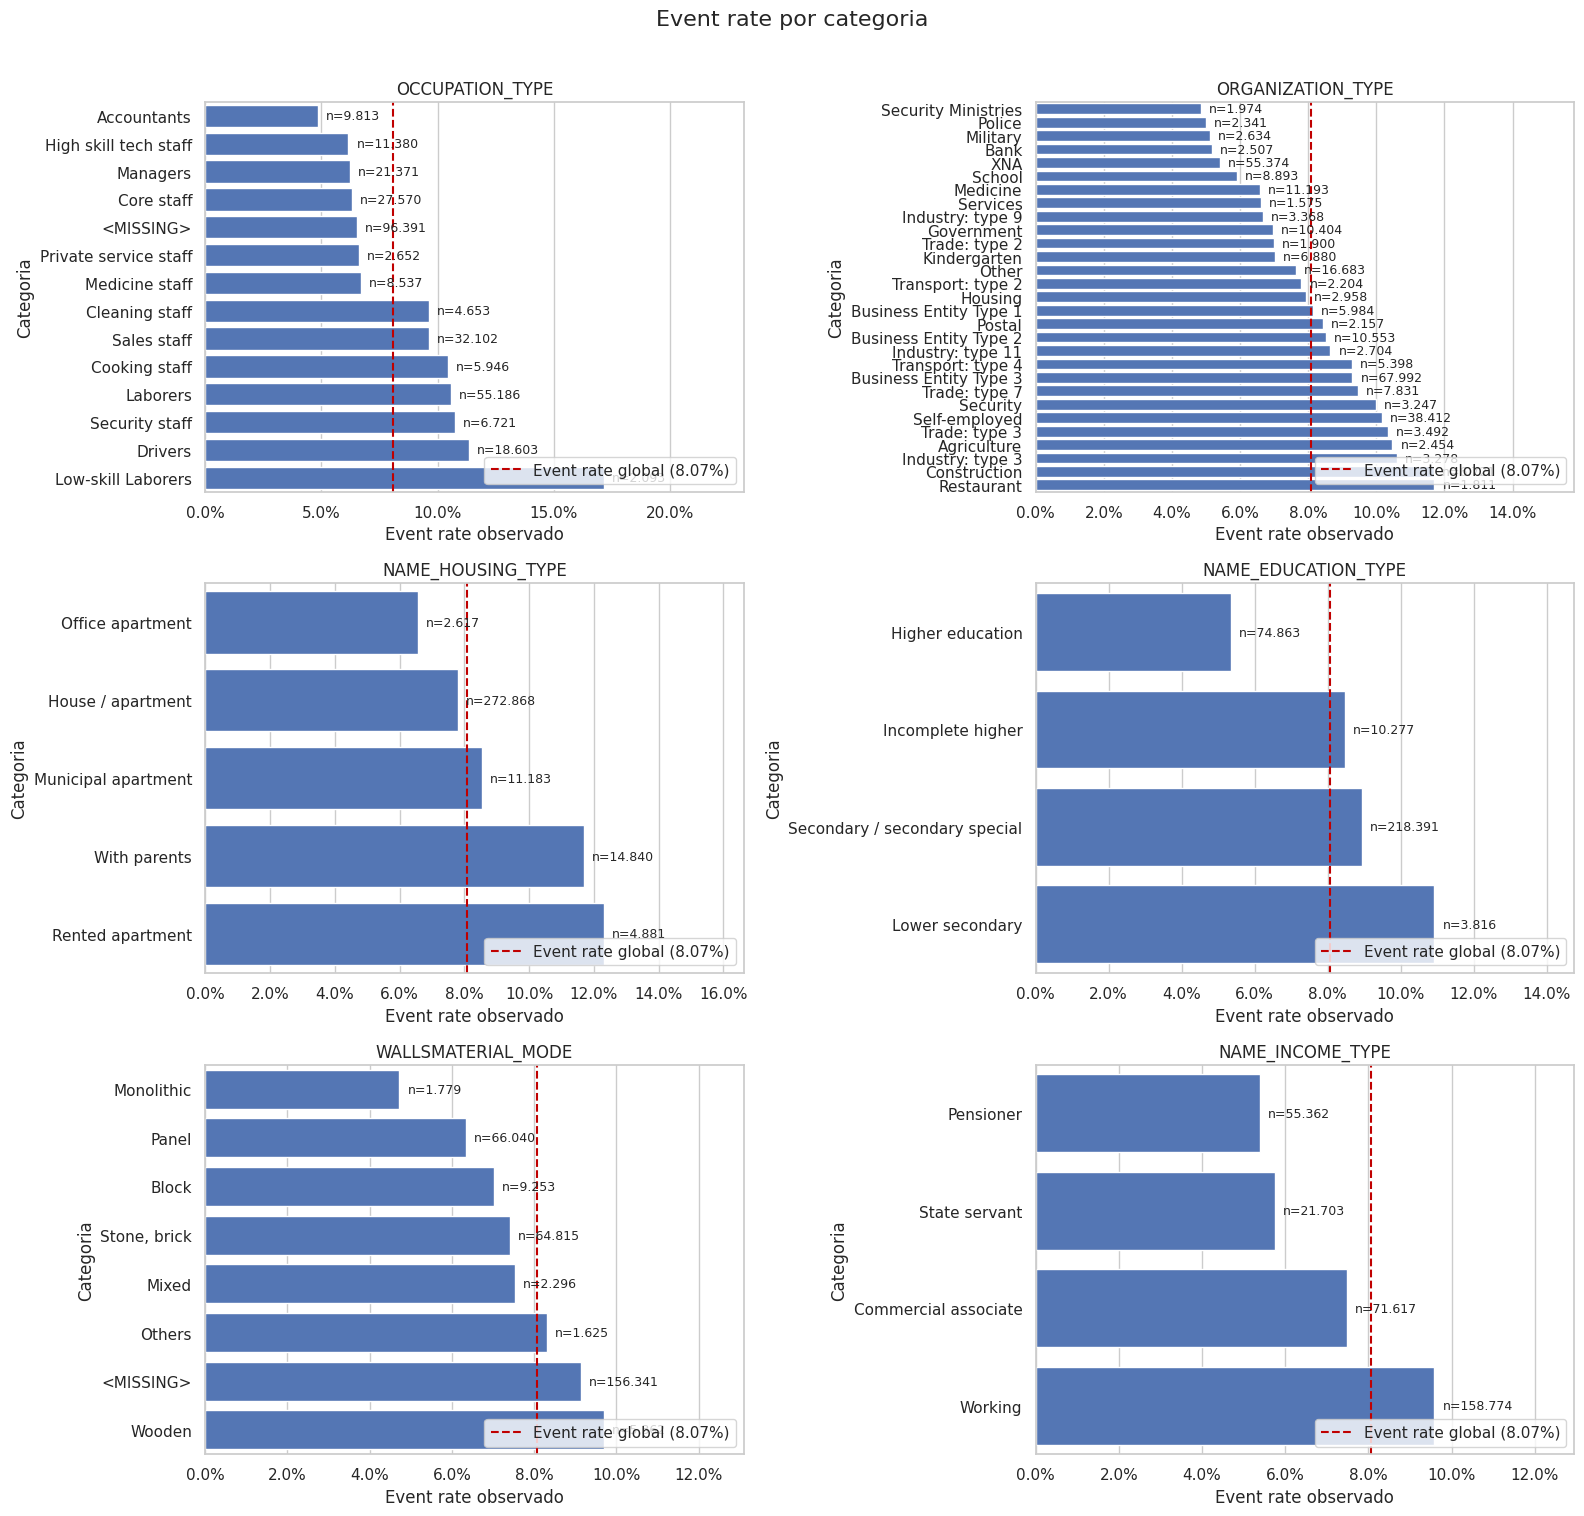

Figura salva em: /content/home-credit-default-risk/reports/figures/application_categorical_event_rate.png


In [29]:
from matplotlib.ticker import PercentFormatter


n_columns = 2
n_rows = int(
    np.ceil(len(top_categorical_variables) / n_columns)
)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(16, 5 * n_rows),
)

axes = np.atleast_1d(axes).flatten()

for axis, variable in zip(
    axes,
    top_categorical_variables,
):
    plot_data = (
        categorical_target_profile
        .query(
            "variable == @variable "
            "and sufficient_support"
        )
        .sort_values("event_rate")
        .copy()
    )

    sns.barplot(
        data=plot_data,
        x="event_rate",
        y="category",
        ax=axis,
        color="#4472C4",
    )

    axis.axvline(
        GLOBAL_EVENT_RATE,
        color="#C00000",
        linestyle="--",
        linewidth=1.5,
        label=(
            "Event rate global "
            f"({GLOBAL_EVENT_RATE:.2%})"
        ),
    )

    maximum_rate = max(
        plot_data["event_rate"].max(),
        GLOBAL_EVENT_RATE,
    )

    axis.set_xlim(
        0,
        min(maximum_rate * 1.35, 1),
    )

    for bar, n_clients in zip(
        axis.patches,
        plot_data["n_clients"],
    ):
        axis.text(
            bar.get_width() + maximum_rate * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"n={n_clients:,}".replace(",", "."),
            va="center",
            fontsize=9,
        )

    axis.set_title(variable)
    axis.set_xlabel("Event rate observado")
    axis.set_ylabel("Categoria")
    axis.xaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )
    axis.legend(loc="lower right")

# Remove eixos não utilizados.
for axis in axes[len(top_categorical_variables):]:
    axis.remove()

fig.suptitle(
    "Event rate por categoria",
    fontsize=16,
    y=1.01,
)

plt.tight_layout()

categorical_event_rate_figure = (
    paths.figures
    / "application_categorical_event_rate.png"
)

plt.savefig(
    categorical_event_rate_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    categorical_event_rate_figure,
)

# Em cada gráfico:

# - A barra representa o event rate observado na categoria.
# - A linha vermelha tracejada representa o event rate global.
# - n representa a quantidade de clientes da categoria.
# - Barras à direita da linha global indicam grupos com incidência de TARGET = 1 acima da média.
# - Barras à esquerda indicam incidência abaixo da média.

In [30]:
top_categorical_results = (
    categorical_target_profile
    .query(
        "variable in @top_categorical_variables "
        "and sufficient_support"
    )
    [
        [
            "variable",
            "category",
            "n_clients",
            "population_share",
            "event_rate",
            "event_rate_difference",
            "event_rate_ratio",
        ]
    ]
    .sort_values(
        ["variable", "event_rate"],
        ascending=[True, False],
    )
)

display(
    top_categorical_results.style.format(
        {
            "n_clients": "{:,.0f}",
            "population_share": "{:.2%}",
            "event_rate": "{:.2%}",
            "event_rate_difference": "{:+.2%}",
            "event_rate_ratio": "{:.2f}",
        }
    )
)

# event_rate_ratio:
# 1,50: event rate 50% superior à média global
# 1,00: event rate igual à média global
# 0,70: event rate 30% inferior à média global.

,variable,category,n_clients,population_share,event_rate,event_rate_difference,event_rate_ratio
28,NAME_EDUCATION_TYPE,Lower secondary,"3,816",1.24%,10.93%,+2.85%,1.35
25,NAME_EDUCATION_TYPE,Secondary / secondary special,"218,391",71.02%,8.94%,+0.87%,1.11
27,NAME_EDUCATION_TYPE,Incomplete higher,"10,277",3.34%,8.48%,+0.41%,1.05
26,NAME_EDUCATION_TYPE,Higher education,"74,863",24.34%,5.36%,-2.72%,0.66
39,NAME_HOUSING_TYPE,Rented apartment,"4,881",1.59%,12.31%,+4.24%,1.53
37,NAME_HOUSING_TYPE,With parents,"14,840",4.83%,11.70%,+3.63%,1.45
38,NAME_HOUSING_TYPE,Municipal apartment,"11,183",3.64%,8.54%,+0.47%,1.06
36,NAME_HOUSING_TYPE,House / apartment,"272,868",88.73%,7.80%,-0.28%,0.97
40,NAME_HOUSING_TYPE,Office apartment,"2,617",0.85%,6.57%,-1.50%,0.81
17,NAME_INCOME_TYPE,Working,"158,774",51.63%,9.59%,+1.52%,1.19


## Análise das Variáveis Numéricas

Nesta seção, serão avaliadas as características das variáveis numéricas presentes na tabela de aplicações.

A análise considerará:

- tipo e cardinalidade;
- medidas descritivas;
- valores ausentes;
- valores extremos e possíveis códigos especiais;
- distribuição das variáveis;
- associação univariada com o `TARGET`.

Embora estejam armazenadas numericamente, algumas variáveis representam identificadores, indicadores binários ou categorias codificadas. Portanto, nem toda coluna numérica deve ser interpretada como uma medida contínua.

### Classificação das variáveis numéricas

As variáveis serão inicialmente separadas em:

- **identificadores:** chaves utilizadas para reconhecer registros;
- **binárias:** possuem até dois valores observados;
- **baixa cardinalidade:** possuem poucos valores distintos e podem representar categorias ou contagens discretas;
- **numéricas gerais:** variáveis contínuas ou discretas com maior cardinalidade.

Essa classificação tem finalidade exploratória e poderá ser revisada durante o desenvolvimento do pipeline de modelagem.

In [31]:
TARGET_COLUMN = "TARGET"
IDENTIFIER_COLUMNS = ["SK_ID_CURR"]
LOW_CARDINALITY_THRESHOLD = 20

numeric_columns = (
    application_train
    .select_dtypes(include=np.number)
    .columns
    .difference([TARGET_COLUMN])
    .tolist()
)

identifier_columns = [
    column
    for column in numeric_columns
    if column in IDENTIFIER_COLUMNS
]

candidate_numeric_columns = [
    column
    for column in numeric_columns
    if column not in identifier_columns
]

numeric_cardinality = (
    application_train[candidate_numeric_columns]
    .nunique(dropna=True)
    .sort_values()
)

binary_numeric_columns = (
    numeric_cardinality[
        numeric_cardinality <= 2
    ]
    .index
    .tolist()
)

low_cardinality_numeric_columns = (
    numeric_cardinality[
        (numeric_cardinality > 2)
        & (
            numeric_cardinality
            <= LOW_CARDINALITY_THRESHOLD
        )
    ]
    .index
    .tolist()
)

general_numeric_columns = (
    numeric_cardinality[
        numeric_cardinality
        > LOW_CARDINALITY_THRESHOLD
    ]
    .index
    .tolist()
)

numeric_classification_summary = pd.DataFrame(
    {
        "classification": [
            "Identificadores",
            "Binárias",
            "Baixa cardinalidade",
            "Numéricas gerais",
        ],
        "n_variables": [
            len(identifier_columns),
            len(binary_numeric_columns),
            len(low_cardinality_numeric_columns),
            len(general_numeric_columns),
        ],
    }
)

display(numeric_classification_summary)

print(
    "Total de colunas numéricas, sem TARGET:",
    len(numeric_columns),
)

,classification,n_variables
0,Identificadores,1
1,Binárias,32
2,Baixa cardinalidade,10
3,Numéricas gerais,62


Total de colunas numéricas, sem TARGET: 105


In [32]:
numeric_classification = pd.concat(
    [
        pd.DataFrame(
            {
                "variable": identifier_columns,
                "classification": "identifier",
            }
        ),
        pd.DataFrame(
            {
                "variable": binary_numeric_columns,
                "classification": "binary",
            }
        ),
        pd.DataFrame(
            {
                "variable": low_cardinality_numeric_columns,
                "classification": "low_cardinality",
            }
        ),
        pd.DataFrame(
            {
                "variable": general_numeric_columns,
                "classification": "general_numeric",
            }
        ),
    ],
    ignore_index=True,
)

numeric_classification["n_unique"] = (
    numeric_classification["variable"]
    .map(
        application_train[
            candidate_numeric_columns
        ].nunique(dropna=True)
    )
)

display(
    numeric_classification.sort_values(
        ["classification", "n_unique", "variable"]
    )
)

,variable,classification,n_unique
22,FLAG_CONT_MOBILE,binary,2.0
26,FLAG_DOCUMENT_10,binary,2.0
25,FLAG_DOCUMENT_11,binary,2.0
17,FLAG_DOCUMENT_12,binary,2.0
18,FLAG_DOCUMENT_13,binary,2.0
...,...,...,...
38,DEF_60_CNT_SOCIAL_CIRCLE,low_cardinality,9.0
39,DEF_30_CNT_SOCIAL_CIRCLE,low_cardinality,10.0
40,AMT_REQ_CREDIT_BUREAU_QRT,low_cardinality,11.0
41,CNT_CHILDREN,low_cardinality,15.0


In [33]:
# perfil descritivo para todas as variáveis numéricas, exceto o identificador:

numeric_analysis_columns = (
    binary_numeric_columns
    + low_cardinality_numeric_columns
    + general_numeric_columns
)

numeric_profile = (
    application_train[numeric_analysis_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "variable",
            "count": "n_non_missing",
            "50%": "median",
        }
    )
)

numeric_profile["n_missing"] = (
    len(application_train)
    - numeric_profile["n_non_missing"]
)

numeric_profile["missing_rate"] = (
    numeric_profile["n_missing"]
    / len(application_train)
)

numeric_profile["n_unique"] = (
    numeric_profile["variable"]
    .map(
        application_train[
            numeric_analysis_columns
        ].nunique(dropna=True)
    )
)

numeric_profile = numeric_profile.merge(
    numeric_classification,
    on=["variable", "n_unique"],
    how="left",
)

numeric_profile = numeric_profile[
    [
        "variable",
        "classification",
        "n_unique",
        "n_non_missing",
        "n_missing",
        "missing_rate",
        "mean",
        "std",
        "min",
        "1%",
        "5%",
        "25%",
        "median",
        "75%",
        "95%",
        "99%",
        "max",
    ]
]

display(
    numeric_profile
    .sort_values(
        ["classification", "variable"]
    )
    .style.format(
        {
            "n_unique": "{:,.0f}",
            "n_non_missing": "{:,.0f}",
            "n_missing": "{:,.0f}",
            "missing_rate": "{:.2%}",
            "mean": "{:,.2f}",
            "std": "{:,.2f}",
            "min": "{:,.2f}",
            "1%": "{:,.2f}",
            "5%": "{:,.2f}",
            "25%": "{:,.2f}",
            "median": "{:,.2f}",
            "75%": "{:,.2f}",
            "95%": "{:,.2f}",
            "99%": "{:,.2f}",
            "max": "{:,.2f}",
        }
    )
)

,variable,classification,n_unique,n_non_missing,n_missing,missing_rate,mean,std,min,1%,5%,25%,median,75%,95%,99%,max
21,FLAG_CONT_MOBILE,binary,2,"307,511",0,0.00%,1.00,0.04,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25,FLAG_DOCUMENT_10,binary,2,"307,511",0,0.00%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
24,FLAG_DOCUMENT_11,binary,2,"307,511",0,0.00%,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
16,FLAG_DOCUMENT_12,binary,2,"307,511",0,0.00%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
17,FLAG_DOCUMENT_13,binary,2,"307,511",0,0.00%,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
18,FLAG_DOCUMENT_14,binary,2,"307,511",0,0.00%,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
19,FLAG_DOCUMENT_15,binary,2,"307,511",0,0.00%,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
20,FLAG_DOCUMENT_16,binary,2,"307,511",0,0.00%,0.01,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
22,FLAG_DOCUMENT_17,binary,2,"307,511",0,0.00%,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
23,FLAG_DOCUMENT_18,binary,2,"307,511",0,0.00%,0.01,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [34]:
# Persistência dos Resultados
numeric_classification_output = (
    paths.tables
    / "application_numeric_classification.csv"
)

numeric_profile_output = (
    paths.tables
    / "application_numeric_profile.csv"
)

numeric_classification.to_csv(
    numeric_classification_output,
    index=False,
)

numeric_profile.to_csv(
    numeric_profile_output,
    index=False,
)

print(
    "Classificação salva em:",
    numeric_classification_output,
)

print(
    "Perfil numérico salvo em:",
    numeric_profile_output,
)

Classificação salva em: /content/home-credit-default-risk/reports/tables/application_numeric_classification.csv
Perfil numérico salvo em: /content/home-credit-default-risk/reports/tables/application_numeric_profile.csv


### Valores especiais e variáveis temporais

Algumas variáveis do conjunto Home Credit representam intervalos de tempo em dias relativos à data da aplicação.

Em geral, esses valores são negativos:

- quanto mais próximo de zero, mais recente é o evento;
- quanto mais negativo, mais antigo é o evento.

Por exemplo, `DAYS_BIRTH = -12000` indica que o cliente nasceu aproximadamente 12.000 dias antes da aplicação.

A variável `DAYS_EMPLOYED` possui ainda o valor positivo `365243`, equivalente a aproximadamente mil anos. Esse valor não representa um tempo de emprego real e deve ser interpretado como um código especial utilizado na base.

Nesta etapa, o valor será apenas identificado e analisado. Seu tratamento será realizado posteriormente no pipeline de preparação dos dados.

In [35]:
# variáveis de dias:
days_columns = [
    column
    for column in application_train.columns
    if column.startswith("DAYS_")
]

print(
    f"Foram encontradas {len(days_columns)} "
    "variáveis iniciadas por DAYS_:"
)

for column in days_columns:
    print(f"- {column}")

Foram encontradas 5 variáveis iniciadas por DAYS_:
- DAYS_BIRTH
- DAYS_EMPLOYED
- DAYS_REGISTRATION
- DAYS_ID_PUBLISH
- DAYS_LAST_PHONE_CHANGE


In [36]:
days_profile = []

for column in days_columns:
    series = application_train[column]

    days_profile.append(
        {
            "variable": column,
            "dtype": str(series.dtype),
            "n_non_missing": series.notna().sum(),
            "n_missing": series.isna().sum(),
            "missing_rate": series.isna().mean(),
            "n_unique": series.nunique(dropna=True),
            "min": series.min(),
            "p01": series.quantile(0.01),
            "median": series.median(),
            "p99": series.quantile(0.99),
            "max": series.max(),
            "n_positive": series.gt(0).sum(),
            "positive_rate": series.gt(0).mean(),
            "n_zero": series.eq(0).sum(),
        }
    )

days_profile = pd.DataFrame(days_profile)

display(
    days_profile.style.format(
        {
            "n_non_missing": "{:,.0f}",
            "n_missing": "{:,.0f}",
            "missing_rate": "{:.2%}",
            "n_unique": "{:,.0f}",
            "min": "{:,.2f}",
            "p01": "{:,.2f}",
            "median": "{:,.2f}",
            "p99": "{:,.2f}",
            "max": "{:,.2f}",
            "n_positive": "{:,.0f}",
            "positive_rate": "{:.2%}",
            "n_zero": "{:,.0f}",
        }
    )
)

,variable,dtype,n_non_missing,n_missing,missing_rate,n_unique,min,p01,median,p99,max,n_positive,positive_rate,n_zero
0,DAYS_BIRTH,int64,"307,511",0,0.00%,"17,460","-25,229.00","-24,419.00","-15,750.00","-8,263.00","-7,489.00",0,0.00%,0
1,DAYS_EMPLOYED,int64,"307,511",0,0.00%,"12,574","-17,912.00","-10,894.90","-1,213.00","365,243.00","365,243.00","55,374",18.01%,2
2,DAYS_REGISTRATION,float64,"307,511",0,0.00%,"15,688","-24,672.00","-13,879.00","-4,504.00",-50.00,0.00,0,0.00%,80
3,DAYS_ID_PUBLISH,int64,"307,511",0,0.00%,"6,168","-7,197.00","-5,447.00","-3,254.00",-61.00,0.00,0,0.00%,16
4,DAYS_LAST_PHONE_CHANGE,float64,"307,510",1,0.00%,"3,773","-4,292.00","-3,149.00",-757.00,0.00,0.00,0,0.00%,"37,672"


In [37]:
# Identificação do código 365243
SPECIAL_DAYS_EMPLOYED_VALUE = 365243

days_employed_special_summary = pd.DataFrame(
    {
        "dataset": [
            "application_train",
            "application_test",
        ],
        "n_records": [
            len(application_train),
            len(application_test),
        ],
        "n_special": [
            application_train["DAYS_EMPLOYED"]
            .eq(SPECIAL_DAYS_EMPLOYED_VALUE)
            .sum(),
            application_test["DAYS_EMPLOYED"]
            .eq(SPECIAL_DAYS_EMPLOYED_VALUE)
            .sum(),
        ],
    }
)

days_employed_special_summary["special_rate"] = (
    days_employed_special_summary["n_special"]
    / days_employed_special_summary["n_records"]
)

display(
    days_employed_special_summary.style.format(
        {
            "n_records": "{:,.0f}",
            "n_special": "{:,.0f}",
            "special_rate": "{:.2%}",
        }
    )
)

,dataset,n_records,n_special,special_rate
0,application_train,"307,511","55,374",18.01%
1,application_test,"48,744","9,274",19.03%


In [38]:
# Avaliação se esse código especial está associado ao TARGET
days_employed_target_analysis = (
    application_train
    .assign(
        DAYS_EMPLOYED_SPECIAL=lambda dataframe: (
            dataframe["DAYS_EMPLOYED"]
            .eq(SPECIAL_DAYS_EMPLOYED_VALUE)
        )
    )
    .groupby(
        "DAYS_EMPLOYED_SPECIAL",
        observed=True,
    )
    .agg(
        n_clients=("TARGET", "size"),
        n_events=("TARGET", "sum"),
        event_rate=("TARGET", "mean"),
    )
    .reset_index()
)

days_employed_target_analysis["population_share"] = (
    days_employed_target_analysis["n_clients"]
    / len(application_train)
)

days_employed_target_analysis[
    "event_rate_difference"
] = (
    days_employed_target_analysis["event_rate"]
    - GLOBAL_EVENT_RATE
)

display(
    days_employed_target_analysis.style.format(
        {
            "n_clients": "{:,.0f}",
            "n_events": "{:,.0f}",
            "population_share": "{:.2%}",
            "event_rate": "{:.2%}",
            "event_rate_difference": "{:+.2%}",
        }
    )
)

# False representa os valores regulares de DAYS_EMPLOYED;
# True representa os registros com o código 365243.

,DAYS_EMPLOYED_SPECIAL,n_clients,n_events,event_rate,population_share,event_rate_difference
0,False,"252,137","21,835",8.66%,81.99%,+0.59%
1,True,"55,374","2,990",5.40%,18.01%,-2.67%


In [39]:
# Distribuições em unidades mais interpretáveis
# Converter idade e tempo de emprego para anos, sem alterar as colunas originais (Apenas para o EDA)

temporal_analysis = pd.DataFrame(
    {
        "TARGET": application_train["TARGET"],
        "AGE_YEARS": (
            -application_train["DAYS_BIRTH"]
            / 365.25
        ),
        "EMPLOYMENT_YEARS": np.where(
            application_train["DAYS_EMPLOYED"]
            .eq(SPECIAL_DAYS_EMPLOYED_VALUE),
            np.nan,
            -application_train["DAYS_EMPLOYED"]
            / 365.25,
        ),
        "DAYS_EMPLOYED_SPECIAL": (
            application_train["DAYS_EMPLOYED"]
            .eq(SPECIAL_DAYS_EMPLOYED_VALUE)
        ),
    }
)

display(
    temporal_analysis[
        ["AGE_YEARS", "EMPLOYMENT_YEARS"]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AGE_YEARS,307511.0,43.9069,11.947950,20.503765,22.622861,25.754962,33.984942,43.121150,53.886379,63.52909,66.855578,69.073238
EMPLOYMENT_YEARS,252137.0,6.5275,6.402081,0.000000,0.303901,0.563997,2.099932,4.511978,8.692676,19.96167,31.042519,49.040383


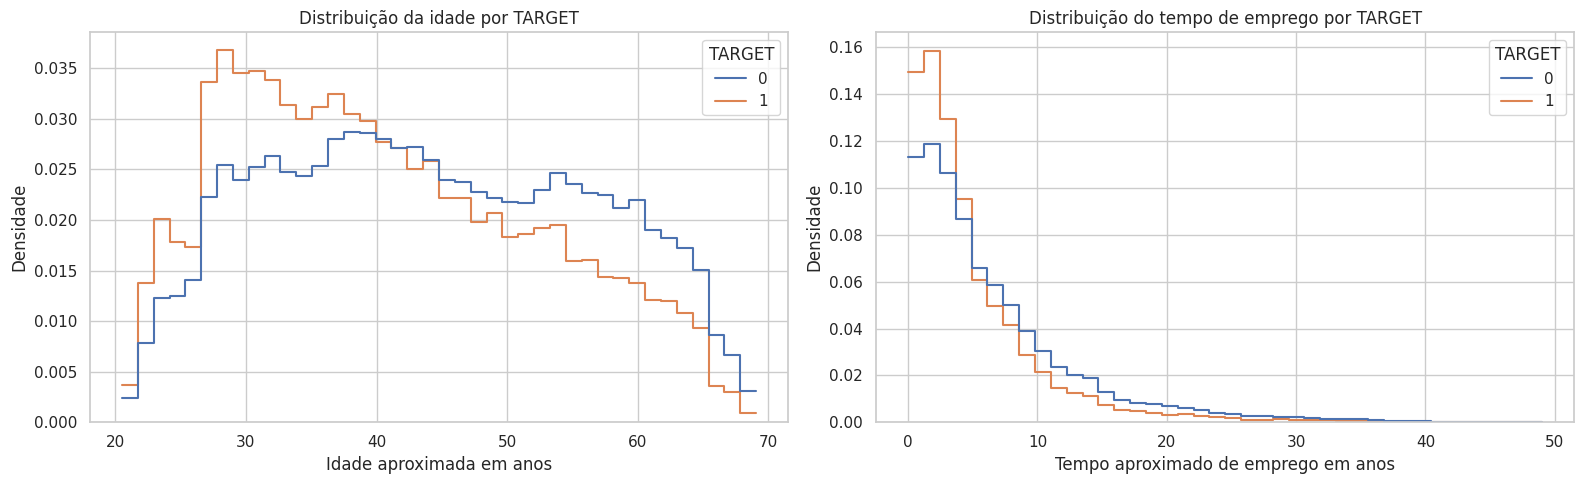

Figura salva em: /content/home-credit-default-risk/reports/figures/application_temporal_distributions.png


In [40]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
)

sns.histplot(
    data=temporal_analysis,
    x="AGE_YEARS",
    hue="TARGET",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[0],
)

axes[0].set_title("Distribuição da idade por TARGET")
axes[0].set_xlabel("Idade aproximada em anos")
axes[0].set_ylabel("Densidade")

sns.histplot(
    data=temporal_analysis,
    x="EMPLOYMENT_YEARS",
    hue="TARGET",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[1],
)

axes[1].set_title(
    "Distribuição do tempo de emprego por TARGET"
)
axes[1].set_xlabel(
    "Tempo aproximado de emprego em anos"
)
axes[1].set_ylabel("Densidade")

plt.tight_layout()

temporal_distribution_figure = (
    paths.figures
    / "application_temporal_distributions.png"
)

plt.savefig(
    temporal_distribution_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    temporal_distribution_figure,
)

In [41]:
# Persistência
days_profile_output = (
    paths.tables
    / "application_days_profile.csv"
)

days_employed_special_output = (
    paths.tables
    / "application_days_employed_special.csv"
)

days_employed_target_output = (
    paths.tables
    / "application_days_employed_target_analysis.csv"
)

days_profile.to_csv(
    days_profile_output,
    index=False,
)

days_employed_special_summary.to_csv(
    days_employed_special_output,
    index=False,
)

days_employed_target_analysis.to_csv(
    days_employed_target_output,
    index=False,
)

print(f"Perfil temporal salvo em: {days_profile_output}")
print(
    "Resumo do código especial salvo em:",
    days_employed_special_output,
)
print(
    "Análise em relação ao TARGET salva em:",
    days_employed_target_output,
)

Perfil temporal salvo em: /content/home-credit-default-risk/reports/tables/application_days_profile.csv
Resumo do código especial salvo em: /content/home-credit-default-risk/reports/tables/application_days_employed_special.csv
Análise em relação ao TARGET salva em: /content/home-credit-default-risk/reports/tables/application_days_employed_target_analysis.csv


### Valores extremos das variáveis financeiras

Variáveis financeiras frequentemente apresentam distribuições assimétricas e caudas longas. Clientes com rendas, créditos ou anuidades elevadas não representam necessariamente erros de dados.

Por isso, valores extremos não serão removidos automaticamente. A análise observará:

- percentis superiores;
- distância entre o percentil 99 e o valor máximo;
- assimetria da distribuição;
- presença de valores nulos, iguais a zero ou negativos;
- diferenças entre clientes com e sem dificuldade de pagamento.

O corte visual no percentil 99 será usado apenas para melhorar a leitura dos gráficos. Ele não altera os dados originais.

In [42]:
# Definição das principais variáveis financeiras:
financial_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

missing_financial_columns = [
    column
    for column in financial_columns
    if column not in application_train.columns
]

if missing_financial_columns:
    raise ValueError(
        "Variáveis financeiras não encontradas: "
        f"{missing_financial_columns}"
    )

In [43]:
# Construção do perfil dos valores extremos
financial_extreme_profile = []

for column in financial_columns:
    series = application_train[column]

    p01 = series.quantile(0.01)
    p50 = series.quantile(0.50)
    p95 = series.quantile(0.95)
    p99 = series.quantile(0.99)
    maximum = series.max()

    financial_extreme_profile.append(
        {
            "variable": column,
            "n_non_missing": series.notna().sum(),
            "n_missing": series.isna().sum(),
            "missing_rate": series.isna().mean(),
            "n_zero": series.eq(0).sum(),
            "n_negative": series.lt(0).sum(),
            "p01": p01,
            "median": p50,
            "p95": p95,
            "p99": p99,
            "max": maximum,
            "max_to_p99_ratio": (
                maximum / p99
                if pd.notna(p99) and p99 != 0
                else np.nan
            ),
            "skewness": series.skew(),
        }
    )

financial_extreme_profile = pd.DataFrame(
    financial_extreme_profile
)

display(
    financial_extreme_profile.style.format(
        {
            "n_non_missing": "{:,.0f}",
            "n_missing": "{:,.0f}",
            "missing_rate": "{:.2%}",
            "n_zero": "{:,.0f}",
            "n_negative": "{:,.0f}",
            "p01": "{:,.2f}",
            "median": "{:,.2f}",
            "p95": "{:,.2f}",
            "p99": "{:,.2f}",
            "max": "{:,.2f}",
            "max_to_p99_ratio": "{:.2f}",
            "skewness": "{:.2f}",
        }
    )
)

,variable,n_non_missing,n_missing,missing_rate,n_zero,n_negative,p01,median,p95,p99,max,max_to_p99_ratio,skewness
0,AMT_INCOME_TOTAL,"307,511",0,0.00%,0,0,"45,000.00","147,150.00","337,500.00","472,500.00","117,000,000.00",247.62,391.56
1,AMT_CREDIT,"307,511",0,0.00%,0,0,"76,410.00","513,531.00","1,350,000.00","1,854,000.00","4,050,000.00",2.18,1.23
2,AMT_ANNUITY,"307,499",12,0.00%,0,0,"6,182.91","24,903.00","53,325.00","70,006.50","258,025.50",3.69,1.58
3,AMT_GOODS_PRICE,"307,233",278,0.09%,0,0,"67,500.00","450,000.00","1,305,000.00","1,800,000.00","4,050,000.00",2.25,1.35


### Interpretação das medidas

A tabela acima apresenta estatísticas destinadas a identificar assimetria, caudas longas e possíveis valores atípicos nas principais variáveis financeiras.

- `n_non_missing`: quantidade de registros com valor preenchido.
- `n_missing`: quantidade de registros sem valor.
- `missing_rate`: proporção de valores ausentes.
- `n_zero`: quantidade de registros com valor igual a zero.
- `n_negative`: quantidade de registros com valor negativo.
- `p01`: valor abaixo do qual estão aproximadamente 1% das observações.
- `median`: valor central da distribuição, também denominado percentil 50.
- `p95`: valor abaixo do qual estão aproximadamente 95% das observações.
- `p99`: valor abaixo do qual estão aproximadamente 99% das observações.
- `max`: maior valor observado.
- `max_to_p99_ratio`: razão entre o valor máximo e o percentil 99.
- `skewness`: medida de assimetria da distribuição.

A razão entre o valor máximo e o percentil 99 é calculada por:

$$
\text{Max-to-P99 Ratio}
=
\frac{\text{Valor máximo}}{\text{Percentil 99}}
$$

A interpretação dessa razão deve ser feita de forma comparativa:

- um valor próximo de `1` indica que o máximo não está muito distante do restante da cauda;
- um valor igual a `5` indica que o máximo é cinco vezes maior que o percentil 99;
- um valor muito elevado indica uma cauda particularmente longa ou a presença de observações que merecem investigação.

A `skewness` indica a direção e a intensidade da assimetria:

- valor próximo de `0`: distribuição aproximadamente simétrica;
- valor positivo: distribuição com cauda mais longa à direita;
- valor negativo: distribuição com cauda mais longa à esquerda;
- quanto maior o valor absoluto, maior a assimetria.

Em variáveis como renda, valor do crédito e anuidade, uma assimetria positiva é esperada. Portanto, valores elevados de `skewness` ou de `max_to_p99_ratio` não comprovam, isoladamente, a existência de erros.

Os valores extremos serão preservados nesta etapa. Possíveis tratamentos, como transformação logarítmica, `binning`, `winsorization` ou aplicação de limites por percentis, deverão ser avaliados posteriormente e ajustados exclusivamente com os dados de treino para evitar `data leakage`.

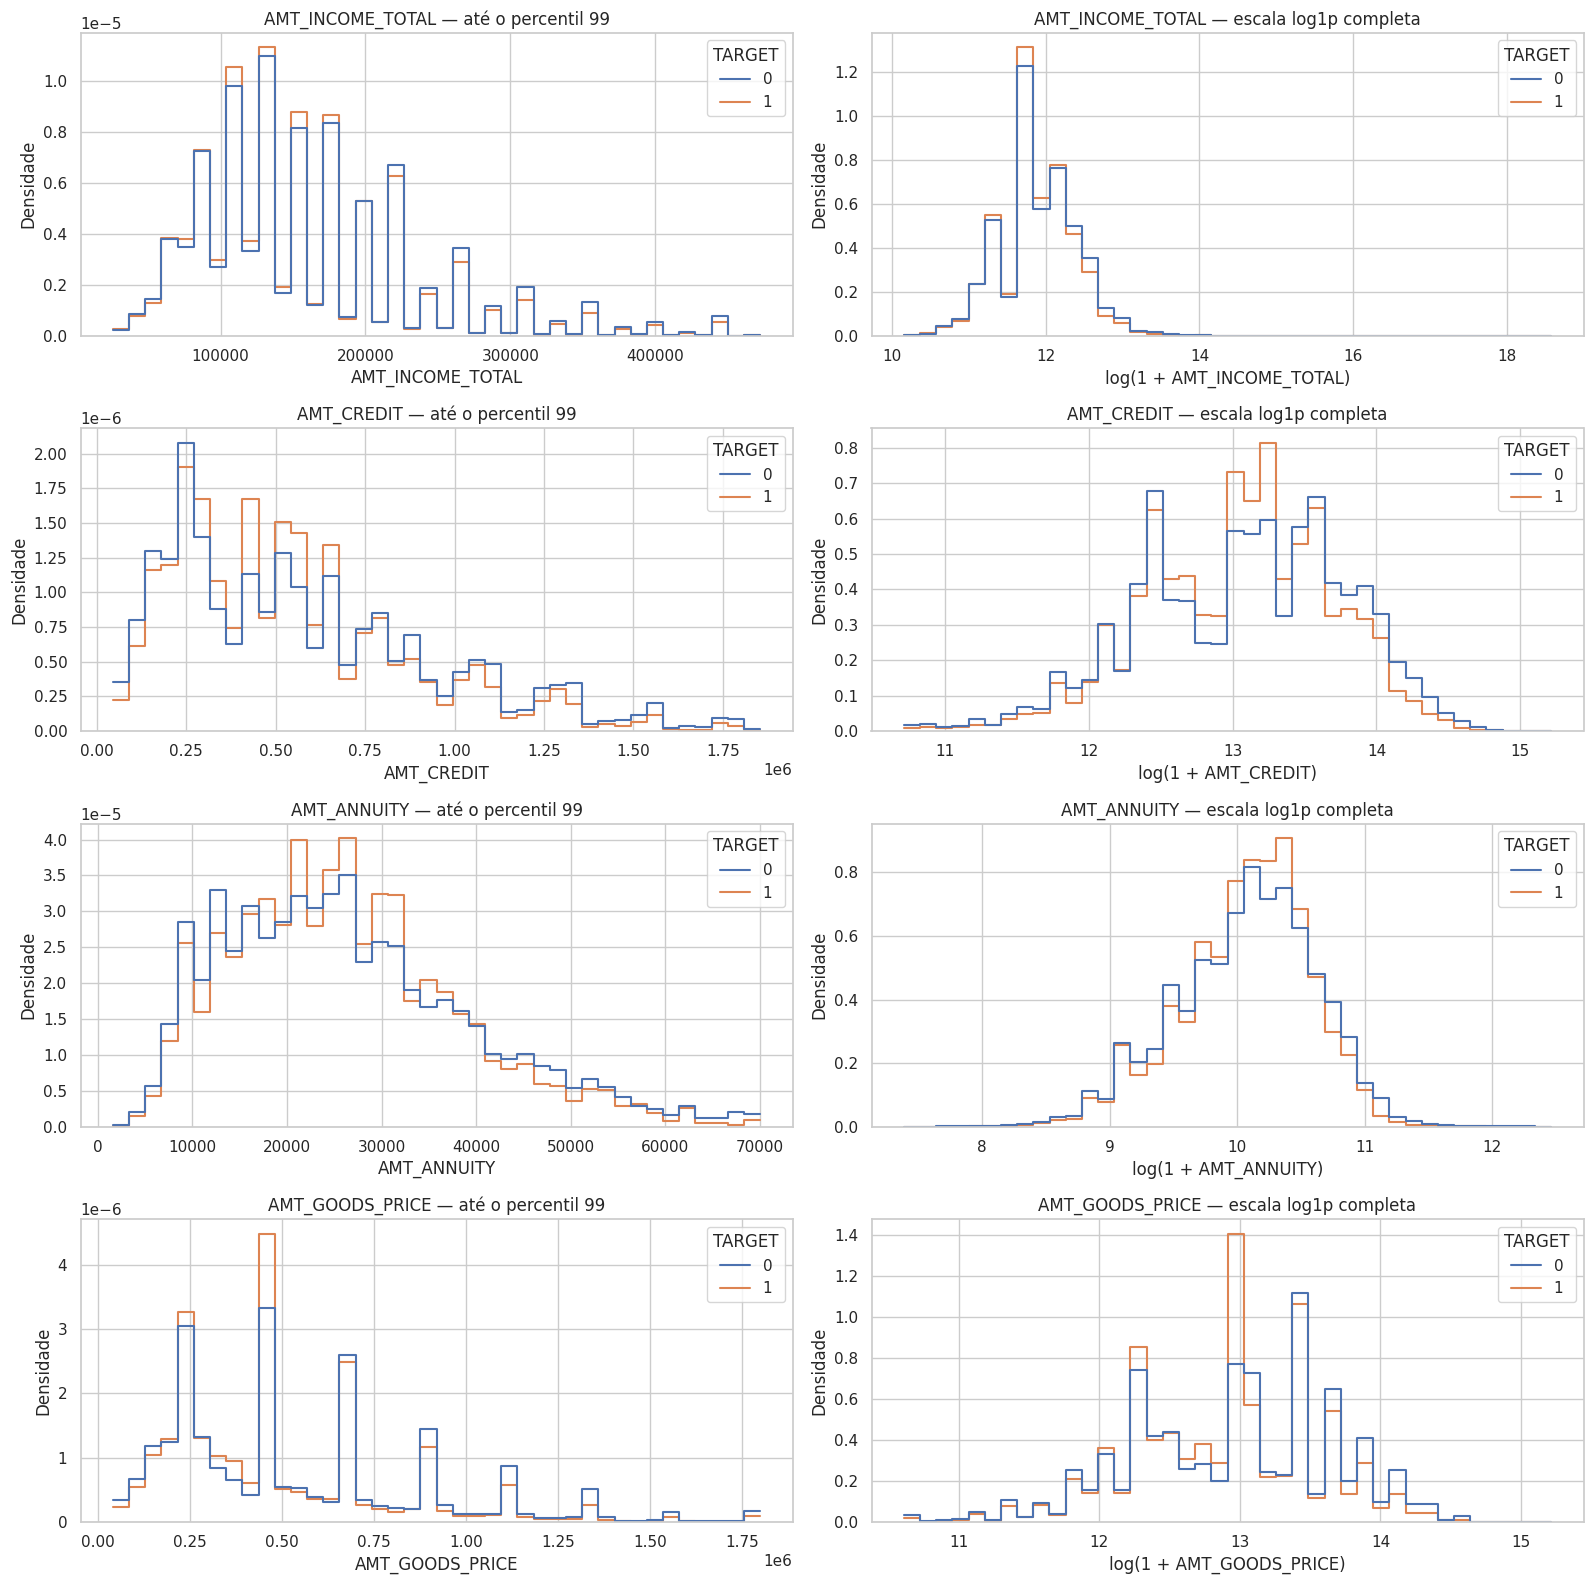

Figura salva em: /content/home-credit-default-risk/reports/figures/application_financial_distributions.png


In [44]:
# Visualização das distribuições
fig, axes = plt.subplots(
    len(financial_columns),
    2,
    figsize=(16, 4 * len(financial_columns)),
)

for row, column in enumerate(financial_columns):
    plot_data = application_train[
        [column, "TARGET"]
    ].dropna()

    p99 = plot_data[column].quantile(0.99)

    central_data = plot_data.loc[
        plot_data[column] <= p99
    ]

    sns.histplot(
        data=central_data,
        x=column,
        hue="TARGET",
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=axes[row, 0],
    )

    axes[row, 0].set_title(
        f"{column} — até o percentil 99"
    )
    axes[row, 0].set_xlabel(column)
    axes[row, 0].set_ylabel("Densidade")

    log_plot_data = plot_data.loc[
        plot_data[column] >= 0
    ].copy()

    log_plot_data["log_value"] = np.log1p(
        log_plot_data[column]
    )

    sns.histplot(
        data=log_plot_data,
        x="log_value",
        hue="TARGET",
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=axes[row, 1],
    )

    axes[row, 1].set_title(
        f"{column} — escala log1p completa"
    )
    axes[row, 1].set_xlabel(
        f"log(1 + {column})"
    )
    axes[row, 1].set_ylabel("Densidade")

plt.tight_layout()

financial_distribution_figure = (
    paths.figures
    / "application_financial_distributions.png"
)

plt.savefig(
    financial_distribution_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    financial_distribution_figure,
)

# O gráfico da esquerda exclui visualmente o 1% superior, mas não modifica a base.
# O gráfico da direita mantém todos os valores e aplica somente uma transformação de escala para facilitar a leitura.

In [45]:
# Comparação por TARGET
financial_target_profile = (
    application_train
    .groupby("TARGET")[financial_columns]
    .agg(
        ["count", "mean", "median"]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "level_0": "variable",
            "level_1": "statistic",
            0: "TARGET_0",
            1: "TARGET_1",
        }
    )
)

financial_target_profile[
    "target_1_to_target_0_ratio"
] = (
    financial_target_profile["TARGET_1"]
    / financial_target_profile["TARGET_0"]
)

display(
    financial_target_profile.style.format(
        {
            "TARGET_0": "{:,.2f}",
            "TARGET_1": "{:,.2f}",
            "target_1_to_target_0_ratio": "{:.3f}",
        }
    )
)

TARGET,variable,statistic,TARGET_0,TARGET_1,target_1_to_target_0_ratio
0,AMT_INCOME_TOTAL,count,"282,686.00","24,825.00",0.088
1,AMT_INCOME_TOTAL,mean,"169,077.72","165,611.76",0.980
2,AMT_INCOME_TOTAL,median,"148,500.00","135,000.00",0.909
3,AMT_CREDIT,count,"282,686.00","24,825.00",0.088
4,AMT_CREDIT,mean,"602,648.28","557,778.53",0.926
5,AMT_CREDIT,median,"517,788.00","497,520.00",0.961
6,AMT_ANNUITY,count,"282,674.00","24,825.00",0.088
7,AMT_ANNUITY,mean,"27,163.62","26,481.74",0.975
8,AMT_ANNUITY,median,"24,876.00","25,263.00",1.016
9,AMT_GOODS_PRICE,count,"282,429.00","24,804.00",0.088


In [46]:
# Persistência
financial_extreme_output = (
    paths.tables
    / "application_financial_extreme_profile.csv"
)

financial_target_output = (
    paths.tables
    / "application_financial_target_profile.csv"
)

financial_extreme_profile.to_csv(
    financial_extreme_output,
    index=False,
)

financial_target_profile.to_csv(
    financial_target_output,
    index=False,
)

print(
    "Perfil de valores extremos salvo em:",
    financial_extreme_output,
)

print(
    "Comparação por TARGET salva em:",
    financial_target_output,
)

Perfil de valores extremos salvo em: /content/home-credit-default-risk/reports/tables/application_financial_extreme_profile.csv
Comparação por TARGET salva em: /content/home-credit-default-risk/reports/tables/application_financial_target_profile.csv


### Associação bivariada das variáveis numéricas com o TARGET

Nesta etapa, cada variável numérica será analisada individualmente em relação ao `TARGET`. Como cada análise envolve uma feature e a variável resposta, trata-se tecnicamente de uma análise bivariada.

A correlação de Spearman será utilizada para avaliar a existência de associação monotônica entre cada variável numérica e o `TARGET`.

Uma associação monotônica ocorre quando o aumento de uma variável tende a acompanhar o aumento ou a redução da outra, mesmo que essa relação não seja linear.

O coeficiente varia entre `-1` e `1`:

- valores positivos indicam que valores maiores da feature tendem a estar associados a maior incidência de `TARGET = 1`;
- valores negativos indicam que valores maiores tendem a estar associados a menor incidência de `TARGET = 1`;
- valores próximos de zero indicam ausência de associação monotônica relevante.

O valor absoluto do coeficiente representa a intensidade da associação, enquanto o sinal representa sua direção.

Embora várias features sejam avaliadas, cada correlação é calculada separadamente. Portanto, esta análise não considera simultaneamente os efeitos conjuntos, as interações ou a redundância entre as variáveis. Esses aspectos serão avaliados posteriormente por meio de análises multivariáveis e dos modelos preditivos.

In [47]:
# Cria uma cópia apenas para essa análise e trate o código especial de DAYS_EMPLOYED
numeric_association_data = application_train[
    numeric_analysis_columns + ["TARGET"]
].copy()

numeric_association_data.loc[
    numeric_association_data["DAYS_EMPLOYED"].eq(
        SPECIAL_DAYS_EMPLOYED_VALUE
    ),
    "DAYS_EMPLOYED",
] = np.nan

In [48]:
#
numeric_target_associations = []

for column in numeric_analysis_columns:
    analysis_data = (
        numeric_association_data[
            [column, "TARGET"]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    n_observations = len(analysis_data)
    n_unique = analysis_data[column].nunique()

    if n_observations == 0 or n_unique < 2:
        correlation = np.nan
        p_value = np.nan
    else:
        correlation, p_value = stats.spearmanr(
            analysis_data[column],
            analysis_data["TARGET"],
        )

    numeric_target_associations.append(
        {
            "variable": column,
            "classification": (
                numeric_classification
                .set_index("variable")
                .loc[column, "classification"]
            ),
            "n_observations": n_observations,
            "n_unique": n_unique,
            "missing_rate": (
                1
                - n_observations
                / len(numeric_association_data)
            ),
            "spearman_correlation": correlation,
            "p_value": p_value,
        }
    )

numeric_target_associations = pd.DataFrame(
    numeric_target_associations
)

numeric_target_associations[
    "absolute_spearman_correlation"
] = (
    numeric_target_associations[
        "spearman_correlation"
    ].abs()
)

numeric_target_associations = (
    numeric_target_associations
    .sort_values(
        "absolute_spearman_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    numeric_target_associations
    .head(30)
    .style.format(
        {
            "n_observations": "{:,.0f}",
            "n_unique": "{:,.0f}",
            "missing_rate": "{:.2%}",
            "spearman_correlation": "{:+.4f}",
            "absolute_spearman_correlation": "{:.4f}",
            "p_value": "{:.3e}",
        }
    )
)

,variable,classification,n_observations,n_unique,missing_rate,spearman_correlation,p_value,absolute_spearman_correlation
0,EXT_SOURCE_3,general_numeric,"246,546",814,19.83%,-0.1663,0.000e+00,0.1663
1,EXT_SOURCE_1,general_numeric,"134,133","114,584",56.38%,-0.1511,0.000e+00,0.1511
2,EXT_SOURCE_2,general_numeric,"306,851","119,831",0.21%,-0.1473,0.000e+00,0.1473
3,DAYS_EMPLOYED,general_numeric,"252,137","12,573",18.01%,+0.0803,0.000e+00,0.0803
4,DAYS_BIRTH,general_numeric,"307,511","17,460",0.00%,+0.0783,0.000e+00,0.0783
5,REGION_RATING_CLIENT_W_CITY,low_cardinality,"307,511",3,0.00%,+0.0609,9.278e-251,0.0609
6,REGION_RATING_CLIENT,low_cardinality,"307,511",3,0.00%,+0.0589,1.804e-234,0.0589
7,DAYS_LAST_PHONE_CHANGE,general_numeric,"307,510","3,773",0.00%,+0.0537,3.267e-195,0.0537
8,OWN_CAR_AGE,general_numeric,"104,582",62,65.99%,+0.0529,8.951e-66,0.0529
9,DAYS_ID_PUBLISH,general_numeric,"307,511","6,168",0.00%,+0.0525,7.751e-187,0.0525


#### Interpretação estatística

O `p-value` testa a hipótese nula de ausência de associação monotônica entre a variável e o `TARGET`.

Entretanto, esta base possui mais de 300 mil observações. Em amostras muito grandes, associações extremamente pequenas podem apresentar `p-values` baixos e serem consideradas estatisticamente significativas sem terem relevância prática.

Por esse motivo, a análise priorizará:

1. magnitude da correlação;
2. coerência do sinal;
3. comportamento do `event rate`;
4. suporte e qualidade dos dados;
5. estabilidade da relação em diferentes amostras.

O `p-value` não será utilizado isoladamente para seleção de variáveis.

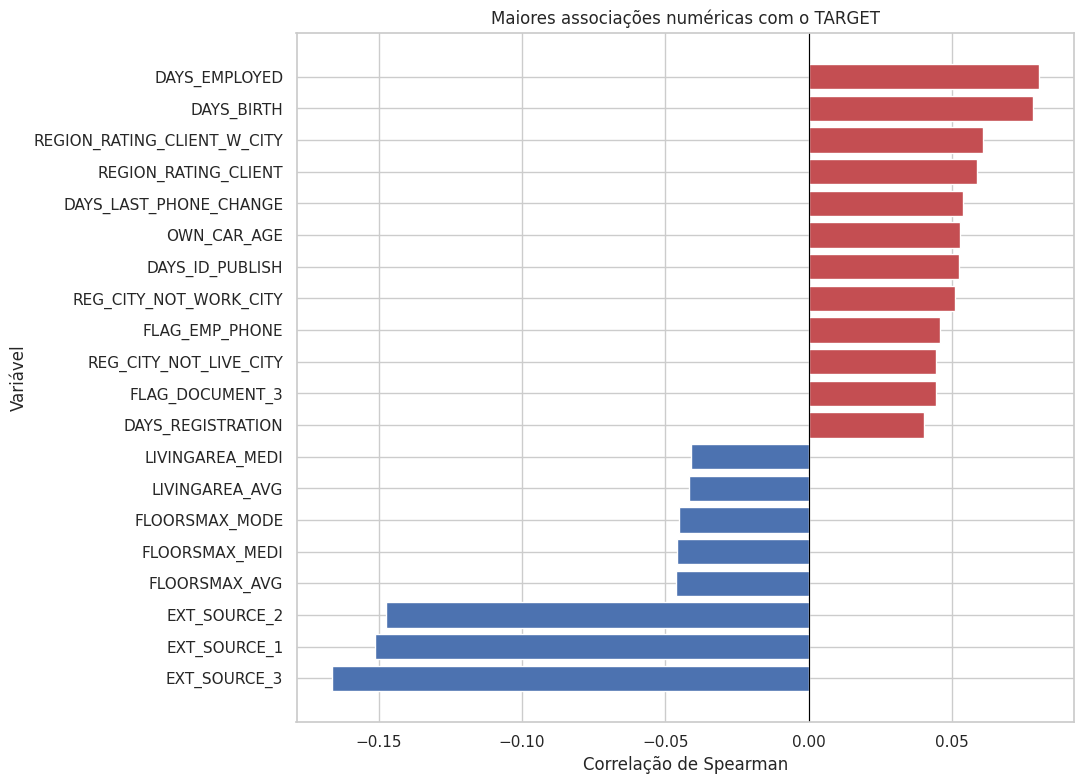

Figura salva em: /content/home-credit-default-risk/reports/figures/application_numeric_target_associations.png


In [49]:
# Visualização das maiores associações
N_NUMERIC_ASSOCIATIONS_TO_PLOT = 20

top_numeric_associations = (
    numeric_target_associations
    .dropna(
        subset=["spearman_correlation"]
    )
    .head(N_NUMERIC_ASSOCIATIONS_TO_PLOT)
    .sort_values("spearman_correlation")
)

correlation_colors = np.where(
    top_numeric_associations[
        "spearman_correlation"
    ] >= 0,
    "#C44E52",
    "#4C72B0",
)

fig, axis = plt.subplots(
    figsize=(11, 8)
)

axis.barh(
    top_numeric_associations["variable"],
    top_numeric_associations[
        "spearman_correlation"
    ],
    color=correlation_colors,
)

axis.axvline(
    0,
    color="black",
    linewidth=0.8,
)

axis.set_title(
    "Maiores associações numéricas com o TARGET"
)
axis.set_xlabel(
    "Correlação de Spearman"
)
axis.set_ylabel("Variável")

plt.tight_layout()

numeric_association_figure = (
    paths.figures
    / "application_numeric_target_associations.png"
)

plt.savefig(
    numeric_association_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    numeric_association_figure,
)

# No gráfico:

# - barras vermelhas indicam associação positiva com dificuldade de pagamento;
# - barras azuis indicam associação negativa;
# - o comprimento da barra representa a intensidade da associação monotônica.

# Uma associação negativa em EXT_SOURCE_1, EXT_SOURCE_2 ou EXT_SOURCE_3, por exemplo, significa que valores maiores desses scores externos tendem a estar associados a menor incidência de TARGET = 1.

In [50]:
# Persistência
numeric_target_associations_output = (
    paths.tables
    / "application_numeric_target_associations.csv"
)

numeric_target_associations.to_csv(
    numeric_target_associations_output,
    index=False,
)

print(
    "Associações numéricas salvas em:",
    numeric_target_associations_output,
)

Associações numéricas salvas em: /content/home-credit-default-risk/reports/tables/application_numeric_target_associations.csv


### Event rate por quantis das variáveis numéricas

A correlação de Spearman resume a direção e a intensidade de uma associação monotônica, mas pode não representar adequadamente relações não lineares.

Para complementar essa análise, as variáveis numéricas serão divididas em até dez grupos com quantidades aproximadamente iguais de clientes, denominados decis:

- `Q01` contém os menores valores da variável;
- `Q10` contém os maiores valores;
- valores ausentes serão mantidos em um grupo separado, denominado `Missing`.

Para cada grupo, serão calculados o número de clientes, a participação na população e o `event rate` observado.

Essa análise permite verificar se o risco:

- aumenta ou diminui de maneira monotônica;
- apresenta mudanças apenas em determinadas faixas;
- possui comportamento não linear;
- está associado à ausência da informação.

In [51]:
# Seleciona as variáveis numéricas gerais com maior associação absoluta
N_QUANTILE_VARIABLES_TO_PLOT = 6
N_QUANTILES = 10

quantile_analysis_variables = (
    numeric_target_associations
    .query(
        "classification == 'general_numeric'"
    )
    .dropna(
        subset=["spearman_correlation"]
    )
    .head(N_QUANTILE_VARIABLES_TO_PLOT)[
        "variable"
    ]
    .tolist()
)

print("Variáveis selecionadas:")

for position, variable in enumerate(
    quantile_analysis_variables,
    start=1,
):
    print(f"{position}. {variable}")

Variáveis selecionadas:
1. EXT_SOURCE_3
2. EXT_SOURCE_1
3. EXT_SOURCE_2
4. DAYS_EMPLOYED
5. DAYS_BIRTH
6. DAYS_LAST_PHONE_CHANGE


In [52]:
# função para construir os decis
def build_numeric_quantile_profile(
    dataframe,
    variable,
    target="TARGET",
    n_quantiles=10,
):
    """
    Calcula suporte e event rate por quantis
    de uma variável numérica.
    """

    analysis_data = dataframe[
        [variable, target]
    ].copy()

    analysis_data[variable] = (
        analysis_data[variable]
        .replace([np.inf, -np.inf], np.nan)
    )

    valid_mask = analysis_data[
        variable
    ].notna()

    n_unique = analysis_data.loc[
        valid_mask,
        variable,
    ].nunique()

    if n_unique < 2:
        return pd.DataFrame()

    effective_quantiles = min(
        n_quantiles,
        n_unique,
    )

    quantile_codes = pd.qcut(
        analysis_data.loc[
            valid_mask,
            variable,
        ],
        q=effective_quantiles,
        labels=False,
        duplicates="drop",
    )

    analysis_data["bin_order"] = np.nan

    analysis_data.loc[
        valid_mask,
        "bin_order",
    ] = (
        quantile_codes
        .astype(int)
        .to_numpy()
        + 1
    )

    observed_quantiles = sorted(
        analysis_data.loc[
            valid_mask,
            "bin_order",
        ]
        .dropna()
        .astype(int)
        .unique()
    )

    quantile_labels = {
        quantile: f"Q{quantile:02d}"
        for quantile in observed_quantiles
    }

    analysis_data["bin"] = (
        analysis_data["bin_order"]
        .map(quantile_labels)
    )

    missing_order = (
        max(observed_quantiles) + 1
    )

    analysis_data.loc[
        ~valid_mask,
        "bin_order",
    ] = missing_order

    analysis_data.loc[
        ~valid_mask,
        "bin",
    ] = "Missing"

    profile = (
        analysis_data
        .groupby(
            ["bin_order", "bin"],
            dropna=False,
        )
        .agg(
            n_clients=(target, "size"),
            n_events=(target, "sum"),
            event_rate=(target, "mean"),
            min_value=(variable, "min"),
            max_value=(variable, "max"),
        )
        .reset_index()
        .sort_values("bin_order")
    )

    profile["population_share"] = (
        profile["n_clients"]
        / len(analysis_data)
    )

    profile["event_rate_difference"] = (
        profile["event_rate"]
        - GLOBAL_EVENT_RATE
    )

    profile["event_rate_ratio"] = (
        profile["event_rate"]
        / GLOBAL_EVENT_RATE
    )

    profile.insert(
        0,
        "variable",
        variable,
    )

    return profile

In [53]:
# Usa a cópia em que o código especial de DAYS_EMPLOYED já foi transformado em NaN
numeric_quantile_profiles = pd.concat(
    [
        build_numeric_quantile_profile(
            numeric_association_data,
            variable,
            target="TARGET",
            n_quantiles=N_QUANTILES,
        )
        for variable in quantile_analysis_variables
    ],
    ignore_index=True,
)

display(
    numeric_quantile_profiles.style.format(
        {
            "bin_order": "{:.0f}",
            "n_clients": "{:,.0f}",
            "n_events": "{:,.0f}",
            "population_share": "{:.2%}",
            "event_rate": "{:.2%}",
            "event_rate_difference": "{:+.2%}",
            "event_rate_ratio": "{:.2f}",
            "min_value": "{:,.4f}",
            "max_value": "{:,.4f}",
        }
    )
)

,variable,bin_order,bin,n_clients,n_events,event_rate,min_value,max_value,population_share,event_rate_difference,event_rate_ratio
0,EXT_SOURCE_3,1,Q01,"24,701","4,941",20.00%,0.0005,0.2276,8.03%,+11.93%,2.48
1,EXT_SOURCE_3,2,Q02,"24,744","3,156",12.75%,0.2289,0.3297,8.05%,+4.68%,1.58
2,EXT_SOURCE_3,3,Q03,"25,057","2,383",9.51%,0.3313,0.4084,8.15%,+1.44%,1.18
3,EXT_SOURCE_3,4,Q04,"24,689","1,970",7.98%,0.4101,0.4758,8.03%,-0.09%,0.99
4,EXT_SOURCE_3,5,Q05,"24,186","1,494",6.18%,0.4776,0.5353,7.87%,-1.90%,0.77
5,EXT_SOURCE_3,6,Q06,"25,392","1,357",5.34%,0.5371,0.5920,8.26%,-2.73%,0.66
6,EXT_SOURCE_3,7,Q07,"24,725","1,173",4.74%,0.5937,0.6430,8.04%,-3.33%,0.59
7,EXT_SOURCE_3,8,Q08,"24,745","1,043",4.21%,0.6447,0.6941,8.05%,-3.86%,0.52
8,EXT_SOURCE_3,9,Q09,"23,675",836,3.53%,0.6956,0.7490,7.70%,-4.54%,0.44
9,EXT_SOURCE_3,10,Q10,"24,632",795,3.23%,0.7504,0.8960,8.01%,-4.85%,0.40


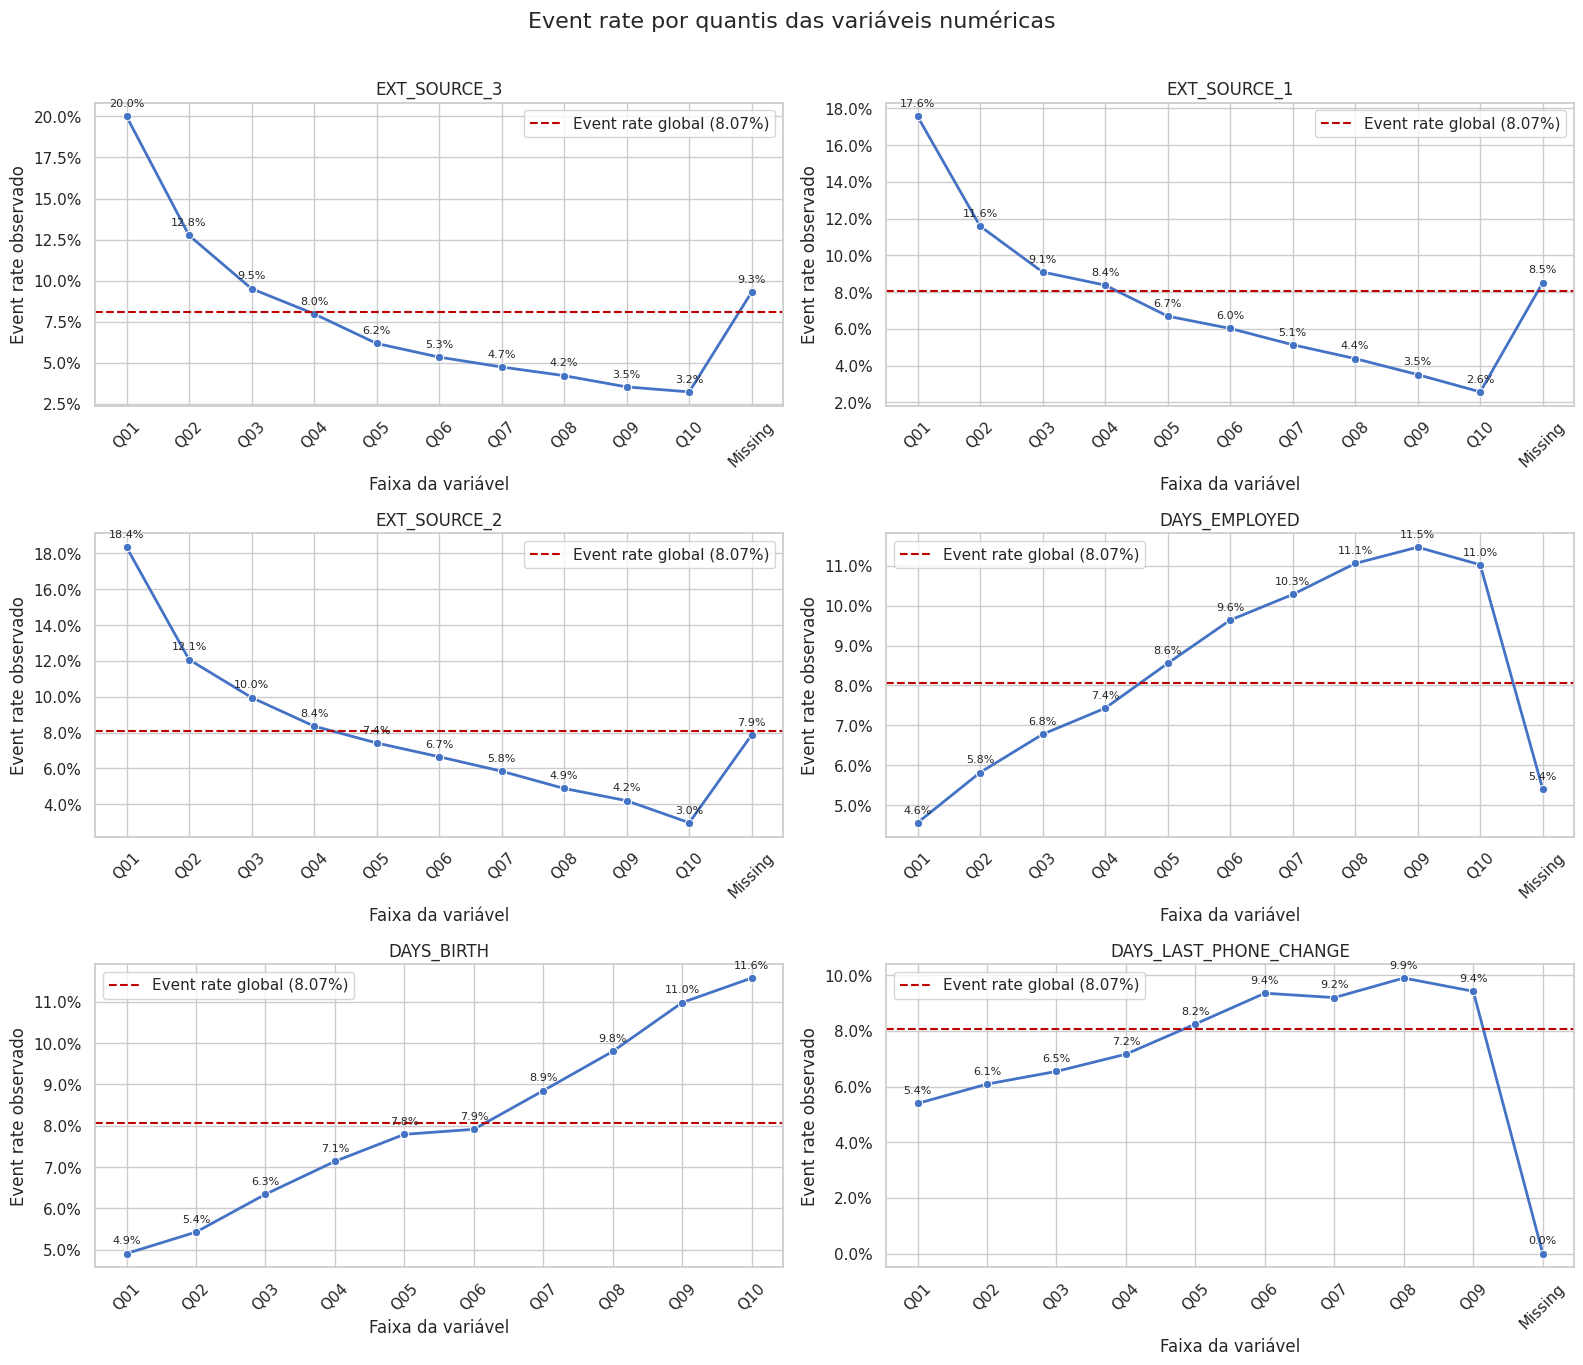

Figura salva em: /content/home-credit-default-risk/reports/figures/application_numeric_quantile_event_rate.png


In [54]:
# Visualização do risco por quantis
n_columns = 2
n_rows = int(
    np.ceil(
        len(quantile_analysis_variables)
        / n_columns
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(16, 4.5 * n_rows),
)

axes = np.atleast_1d(axes).flatten()

for axis, variable in zip(
    axes,
    quantile_analysis_variables,
):
    plot_data = (
        numeric_quantile_profiles
        .query("variable == @variable")
        .sort_values("bin_order")
        .copy()
    )

    sns.lineplot(
        data=plot_data,
        x="bin",
        y="event_rate",
        marker="o",
        linewidth=2,
        color="#4472C4",
        ax=axis,
    )

    axis.axhline(
        GLOBAL_EVENT_RATE,
        color="#C00000",
        linestyle="--",
        linewidth=1.5,
        label=(
            "Event rate global "
            f"({GLOBAL_EVENT_RATE:.2%})"
        ),
    )

    for _, row in plot_data.iterrows():
        axis.annotate(
            f"{row['event_rate']:.1%}",
            (
                row["bin"],
                row["event_rate"],
            ),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8,
        )

    axis.set_title(variable)
    axis.set_xlabel(
        "Faixa da variável"
    )
    axis.set_ylabel(
        "Event rate observado"
    )
    axis.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )
    axis.tick_params(
        axis="x",
        rotation=45,
    )
    axis.legend(loc="best")

for axis in axes[
    len(quantile_analysis_variables):
]:
    axis.remove()

fig.suptitle(
    "Event rate por quantis das variáveis numéricas",
    fontsize=16,
    y=1.01,
)

plt.tight_layout()

numeric_quantile_figure = (
    paths.figures
    / "application_numeric_quantile_event_rate.png"
)

plt.savefig(
    numeric_quantile_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    numeric_quantile_figure,
)

#### Interpretação dos resultados por quantis

Os gráficos devem ser interpretados da esquerda para a direita:

- `Q01` representa os menores valores da variável;
- os quantis intermediários representam faixas progressivamente maiores;
- `Q10` representa os maiores valores;
- `Missing`, quando presente, representa clientes sem informação disponível.

Uma sequência continuamente crescente ou decrescente sugere uma relação monotônica com o risco. Nesse caso, a direção observada deve ser coerente com o sinal da correlação de Spearman.

Oscilações entre os quantis podem indicar:

- relação não linear;
- concentração de risco apenas nos extremos;
- interação com outras variáveis;
- instabilidade amostral;
- necessidade de agrupamento por `binning`.

O grupo `Missing` deve ser analisado como uma população própria. Se apresentar `event rate` diferente da média global, a ausência da informação pode possuir valor preditivo.

As fronteiras dos quantis foram calculadas sobre a base utilizada nesta EDA apenas para fins exploratórios. No pipeline de modelagem, qualquer definição de faixas deverá ser ajustada exclusivamente na amostra de treino e posteriormente aplicada às amostras de validação e teste, evitando `data leakage`.

In [55]:
# Persistência
numeric_quantile_output = (
    paths.tables
    / "application_numeric_quantile_profiles.csv"
)

numeric_quantile_profiles.to_csv(
    numeric_quantile_output,
    index=False,
)

print(
    "Perfil por quantis salvo em:",
    numeric_quantile_output,
)

Perfil por quantis salvo em: /content/home-credit-default-risk/reports/tables/application_numeric_quantile_profiles.csv


## Correlação entre variáveis numéricas

A análise anterior relacionou separadamente cada feature com o `TARGET`. Nesta etapa, será avaliada a associação entre as próprias variáveis numéricas.

Os principais objetivos são:

- identificar features que representam informações semelhantes;
- encontrar possíveis redundâncias;
- reconhecer grupos de variáveis derivadas da mesma informação;
- antecipar problemas de multicolinearidade na regressão logística.

Será utilizada novamente a correlação de Spearman, pois muitas variáveis possuem distribuições assimétricas e relações que podem ser monotônicas sem serem lineares.

Uma correlação elevada entre duas features não implica que uma delas deva ser automaticamente removida. A decisão também deverá considerar significado de negócio, qualidade dos dados, estabilidade, missing e contribuição preditiva.

In [56]:
# Cálculo da matriz de correlação
# Para controlar o tempo e o consumo de memória, vamos utilizar uma amostra reprodutível de até 100 mil registros:

CORRELATION_SAMPLE_SIZE = 100_000
CORRELATION_RANDOM_STATE = 42
HIGH_CORRELATION_THRESHOLD = 0.80

correlation_variables = (
    general_numeric_columns
)

available_sample_size = min(
    CORRELATION_SAMPLE_SIZE,
    len(numeric_association_data),
)

correlation_sample = (
    numeric_association_data[
        correlation_variables
    ]
    .sample(
        n=available_sample_size,
        random_state=CORRELATION_RANDOM_STATE,
    )
)

print(
    "Registros utilizados na matriz:",
    f"{len(correlation_sample):,}"
    .replace(",", "."),
)

print(
    "Variáveis utilizadas:",
    len(correlation_variables),
)

Registros utilizados na matriz: 100.000
Variáveis utilizadas: 62


In [57]:
# Cálculo da matriz
numeric_feature_correlation = (
    correlation_sample
    .corr(
        method="spearman",
        min_periods=1_000,
    )
)

display(
    numeric_feature_correlation.iloc[
        :10,
        :10,
    ].style.format("{:.3f}")
)

,AMT_REQ_CREDIT_BUREAU_MON,HOUR_APPR_PROCESS_START,FLOORSMIN_MODE,FLOORSMAX_MODE,AMT_REQ_CREDIT_BUREAU_YEAR,ELEVATORS_MODE,ENTRANCES_MODE,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,ELEVATORS_MEDI
AMT_REQ_CREDIT_BUREAU_MON,1.000,0.028,0.023,0.033,0.020,0.029,0.005,-0.003,-0.002,0.029
HOUR_APPR_PROCESS_START,0.028,1.000,0.094,0.101,-0.042,0.102,0.010,-0.018,-0.018,0.105
FLOORSMIN_MODE,0.023,0.094,1.000,0.643,-0.009,0.561,0.077,-0.032,-0.032,0.556
FLOORSMAX_MODE,0.033,0.101,0.643,1.000,-0.021,0.833,0.169,-0.038,-0.038,0.827
AMT_REQ_CREDIT_BUREAU_YEAR,0.020,-0.042,-0.009,-0.021,1.000,-0.019,-0.007,0.021,0.021,-0.021
ELEVATORS_MODE,0.029,0.102,0.561,0.833,-0.019,1.000,0.135,-0.043,-0.043,0.978
ENTRANCES_MODE,0.005,0.010,0.077,0.169,-0.007,0.135,1.000,0.003,0.003,0.117
OBS_30_CNT_SOCIAL_CIRCLE,-0.003,-0.018,-0.032,-0.038,0.021,-0.043,0.003,1.000,0.997,-0.045
OBS_60_CNT_SOCIAL_CIRCLE,-0.002,-0.018,-0.032,-0.038,0.021,-0.043,0.003,0.997,1.000,-0.045
ELEVATORS_MEDI,0.029,0.105,0.556,0.827,-0.021,0.978,0.117,-0.045,-0.045,1.000


In [58]:
# Identificação dos pares altamente correlacionados
upper_triangle_mask = np.triu(
    np.ones(
        numeric_feature_correlation.shape,
        dtype=bool,
    ),
    k=1,
)

upper_triangle_correlation = (
    numeric_feature_correlation
    .where(upper_triangle_mask)
)

high_correlation_pairs = (
    upper_triangle_correlation
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "spearman_correlation",
]

high_correlation_pairs[
    "absolute_spearman_correlation"
] = (
    high_correlation_pairs[
        "spearman_correlation"
    ].abs()
)

high_correlation_pairs = (
    high_correlation_pairs
    .query(
        "absolute_spearman_correlation "
        ">= @HIGH_CORRELATION_THRESHOLD"
    )
    .sort_values(
        "absolute_spearman_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Pares com correlação absoluta "
    f"maior ou igual a "
    f"{HIGH_CORRELATION_THRESHOLD:.0%}: "
    f"{len(high_correlation_pairs)}"
)

display(
    high_correlation_pairs
    .head(50)
    .style.format(
        {
            "spearman_correlation": "{:+.4f}",
            "absolute_spearman_correlation": "{:.4f}",
        }
    )
)

Pares com correlação absoluta maior ou igual a 80%: 100


,variable_1,variable_2,spearman_correlation,absolute_spearman_correlation
0,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,+0.9985,0.9985
1,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,+0.9973,0.9973
2,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,+0.9971,0.9971
3,LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_AVG,+0.9965,0.9965
4,COMMONAREA_AVG,COMMONAREA_MEDI,+0.9964,0.9964
5,LANDAREA_AVG,LANDAREA_MEDI,+0.9962,0.9962
6,FLOORSMIN_MEDI,FLOORSMIN_AVG,+0.9961,0.9961
7,LIVINGAREA_AVG,LIVINGAREA_MEDI,+0.9958,0.9958
8,APARTMENTS_MEDI,APARTMENTS_AVG,+0.9954,0.9954
9,BASEMENTAREA_MEDI,BASEMENTAREA_AVG,+0.9950,0.9950


### Interpretação dos pares altamente correlacionados

A correlação absoluta será utilizada para identificar tanto relações positivas quanto negativas:

$$
|\rho| \geq 0{,}80
$$

onde $\rho$ representa o coeficiente de correlação de Spearman.

- correlação próxima de `1`: as variáveis tendem a crescer conjuntamente;
- correlação próxima de `-1`: o crescimento de uma tende a acompanhar a redução da outra;
- correlação próxima de `0`: não há associação monotônica forte.

No conjunto Home Credit, é esperado encontrar correlações elevadas entre alguns grupos, como:

- valor do crédito e valor do bem financiado;
- características do imóvel representadas pelos sufixos `_AVG`, `_MODE` e `_MEDI`;
- diferentes contagens de documentos ou ocorrências;
- indicadores derivados de uma mesma fonte cadastral.

Para a regressão logística, grupos de variáveis altamente correlacionadas podem produzir coeficientes instáveis, dificultar a interpretação e aumentar a sensibilidade do modelo à amostra de treino.

Para modelos baseados em árvores, como LightGBM, a multicolinearidade geralmente não compromete diretamente a capacidade preditiva. Entretanto, features redundantes ainda podem aumentar a complexidade e distribuir a importância entre variáveis semelhantes.

Nenhuma feature será removida nesta etapa. Os pares identificados serão utilizados posteriormente como apoio para seleção de variáveis.

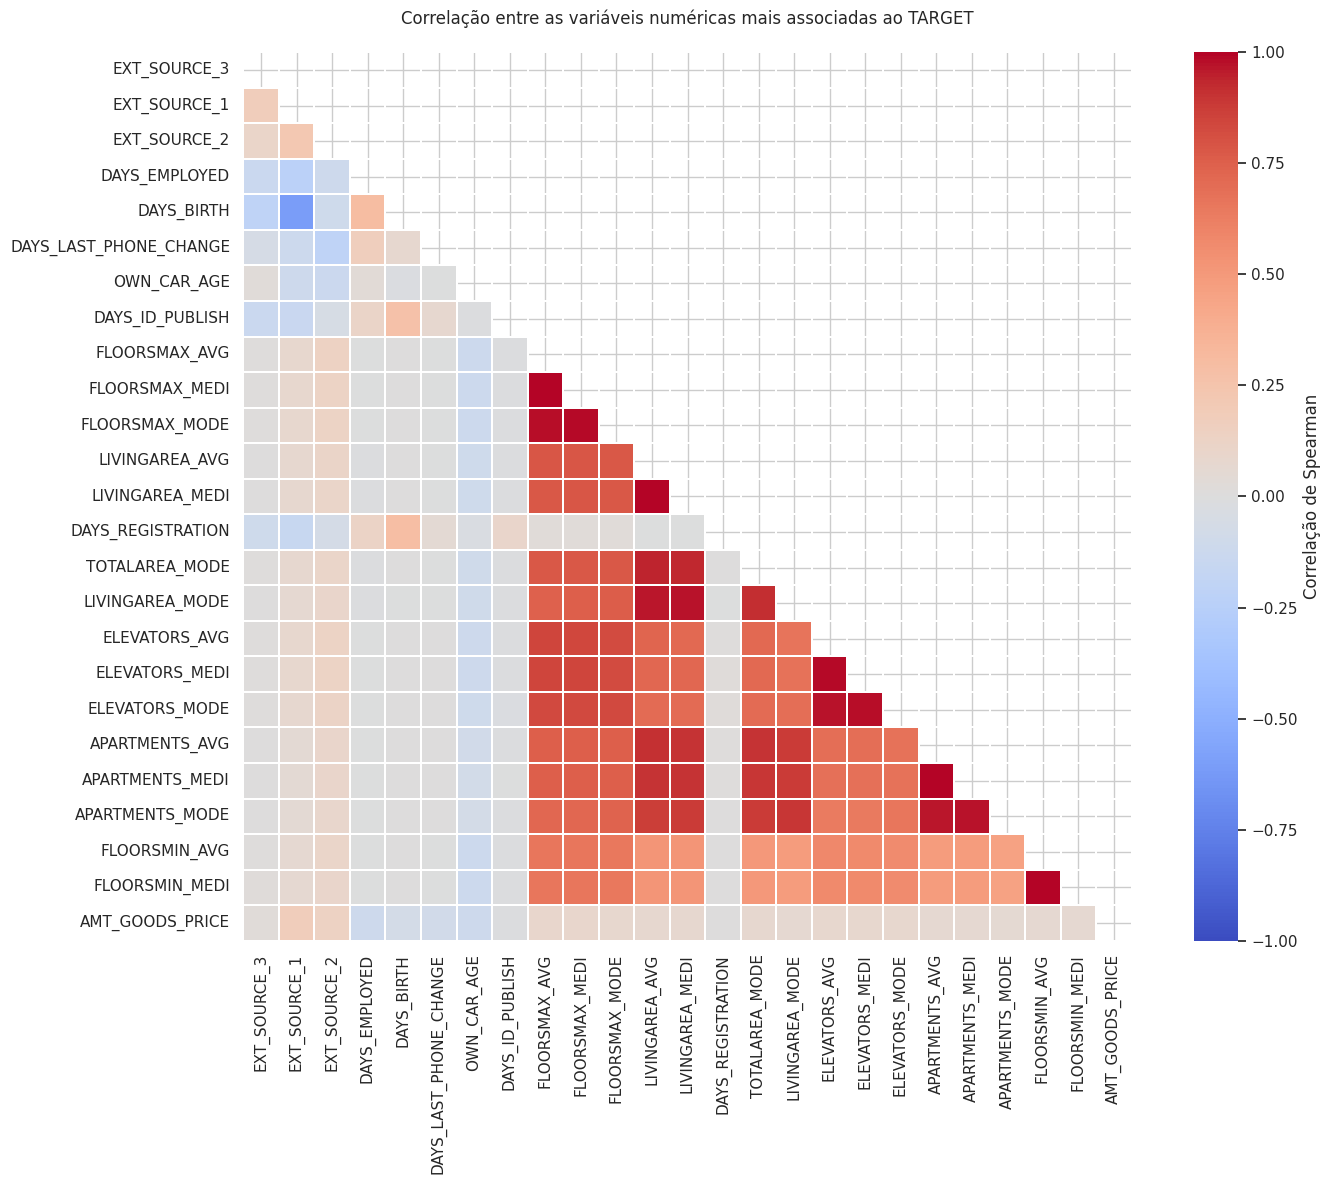

Figura salva em: /content/home-credit-default-risk/reports/figures/application_numeric_correlation_heatmap.png


In [59]:
# Matriz de correlação das features mais associadas ao TARGET
N_CORRELATION_HEATMAP_VARIABLES = 25

heatmap_variables = (
    numeric_target_associations
    .query(
        "classification == 'general_numeric'"
    )
    .dropna(
        subset=[
            "absolute_spearman_correlation"
        ]
    )
    .head(
        N_CORRELATION_HEATMAP_VARIABLES
    )["variable"]
    .tolist()
)

heatmap_correlation = (
    numeric_feature_correlation
    .loc[
        heatmap_variables,
        heatmap_variables,
    ]
)

heatmap_mask = np.triu(
    np.ones_like(
        heatmap_correlation,
        dtype=bool,
    )
)

fig, axis = plt.subplots(
    figsize=(15, 12)
)

sns.heatmap(
    heatmap_correlation,
    mask=heatmap_mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={
        "label": "Correlação de Spearman"
    },
    ax=axis,
)

axis.set_title(
    "Correlação entre as variáveis numéricas "
    "mais associadas ao TARGET",
    pad=20,
)

plt.tight_layout()

numeric_correlation_figure = (
    paths.figures
    / "application_numeric_correlation_heatmap.png"
)

plt.savefig(
    numeric_correlation_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    numeric_correlation_figure,
)

#### Cuidados na interpretação da matriz

A correlação entre features é uma análise bivariada: cada coeficiente considera somente um par de variáveis.

Consequentemente, essa matriz:

- não identifica todas as formas de relação não linear;
- não mede diretamente causalidade;
- não mostra o efeito conjunto de várias features;
- não comprova, isoladamente, a existência de multicolinearidade;
- pode ser influenciada pela presença de valores ausentes.

A multicolinearidade será avaliada com maior profundidade durante a construção da regressão logística, considerando também estabilidade dos coeficientes, significado das variáveis e, se necessário, métricas como o `Variance Inflation Factor` — VIF.

In [60]:
numeric_correlation_output = (
    paths.tables
    / "application_numeric_spearman_correlation.csv"
)

high_correlation_pairs_output = (
    paths.tables
    / "application_high_correlation_pairs.csv"
)

numeric_feature_correlation.to_csv(
    numeric_correlation_output,
)

high_correlation_pairs.to_csv(
    high_correlation_pairs_output,
    index=False,
)

print(
    "Matriz de correlação salva em:",
    numeric_correlation_output,
)

print(
    "Pares altamente correlacionados salvos em:",
    high_correlation_pairs_output,
)

Matriz de correlação salva em: /content/home-credit-default-risk/reports/tables/application_numeric_spearman_correlation.csv
Pares altamente correlacionados salvos em: /content/home-credit-default-risk/reports/tables/application_high_correlation_pairs.csv


In [61]:
# Persistência
numeric_correlation_output = (
    paths.tables
    / "application_numeric_spearman_correlation.csv"
)

high_correlation_pairs_output = (
    paths.tables
    / "application_high_correlation_pairs.csv"
)

numeric_feature_correlation.to_csv(
    numeric_correlation_output,
)

high_correlation_pairs.to_csv(
    high_correlation_pairs_output,
    index=False,
)

print(
    "Matriz de correlação salva em:",
    numeric_correlation_output,
)

print(
    "Pares altamente correlacionados salvos em:",
    high_correlation_pairs_output,
)

Matriz de correlação salva em: /content/home-credit-default-risk/reports/tables/application_numeric_spearman_correlation.csv
Pares altamente correlacionados salvos em: /content/home-credit-default-risk/reports/tables/application_high_correlation_pairs.csv


## Feature engineering exploratória

Valores absolutos de renda, crédito e anuidade não representam integralmente a capacidade de pagamento do cliente. Um mesmo valor de crédito pode ter impactos diferentes para clientes com níveis distintos de renda.

Nesta etapa, serão criadas algumas razões financeiras candidatas:

- `CREDIT_INCOME_RATIO`: valor do crédito em relação à renda;
- `ANNUITY_INCOME_RATIO`: anuidade em relação à renda;
- `CREDIT_ANNUITY_RATIO`: relação entre o crédito e a anuidade;
- `CREDIT_GOODS_RATIO`: crédito em relação ao valor do bem;
- `INCOME_PER_PERSON`: renda dividida pelo número de integrantes da família.

Essas features serão utilizadas apenas para análise exploratória. Sua criação definitiva será implementada posteriormente em um pipeline reprodutível, com regras ajustadas nos dados de treino.

### Definição das razões financeiras

As razões candidatas possuem as seguintes interpretações:

#### Credit-to-Income

$$
\text{Credit-to-Income}
=
\frac{\text{AMT_CREDIT}}
{\text{AMT_INCOME_TOTAL}}
$$

Representa o tamanho do crédito solicitado em relação à renda declarada. Valores elevados indicam uma exposição maior em relação à capacidade financeira informada.

#### Annuity-to-Income

$$
\text{Annuity-to-Income}
=
\frac{\text{AMT_ANNUITY}}
{\text{AMT_INCOME_TOTAL}}
$$

Representa o comprometimento relativo da renda com a anuidade da operação. É uma aproximação de esforço financeiro, mas não corresponde necessariamente ao comprometimento total da renda, pois a base não informa todas as obrigações financeiras atuais do cliente.

#### Credit-to-Annuity

$$
\text{Credit-to-Annuity}
=
\frac{\text{AMT_CREDIT}}
{\text{AMT_ANNUITY}}
$$

Relaciona o valor do crédito à anuidade. Pode funcionar como uma aproximação da duração financeira da operação, mas não deve ser interpretada diretamente como número exato de parcelas, pois não considera explicitamente juros, periodicidade e estrutura contratual.

#### Credit-to-Goods

$$
\text{Credit-to-Goods}
=
\frac{\text{AMT_CREDIT}}
{\text{AMT_GOODS_PRICE}}
$$

Compara o crédito concedido com o preço do bem. Valores superiores a `1` indicam que o crédito registrado é maior que o valor do bem, possivelmente incorporando custos adicionais.

#### Income per Person

$$
\text{Income per Person}
=
\frac{\text{AMT_INCOME_TOTAL}}
{\text{CNT_FAM_MEMBERS}}
$$

Representa uma aproximação da renda disponível por integrante da família. Essa medida não considera a distribuição efetiva da renda nem as despesas familiares.

In [62]:
# Função para construção
def safe_divide(numerator, denominator):
    """
    Realiza divisão somente quando o denominador
    é preenchido, finito e maior que zero.
    """

    valid_denominator = (
        denominator.notna()
        & np.isfinite(denominator)
        & denominator.gt(0)
    )

    result = pd.Series(
        np.nan,
        index=numerator.index,
        dtype="float64",
    )

    result.loc[valid_denominator] = (
        numerator.loc[valid_denominator]
        / denominator.loc[valid_denominator]
    )

    return result

In [63]:
# Construção da base exploratória
financial_feature_data = application_train[
    [
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "CNT_FAM_MEMBERS",
    ]
].copy()

financial_feature_data[
    "CREDIT_INCOME_RATIO"
] = safe_divide(
    financial_feature_data["AMT_CREDIT"],
    financial_feature_data["AMT_INCOME_TOTAL"],
)

financial_feature_data[
    "ANNUITY_INCOME_RATIO"
] = safe_divide(
    financial_feature_data["AMT_ANNUITY"],
    financial_feature_data["AMT_INCOME_TOTAL"],
)

financial_feature_data[
    "CREDIT_ANNUITY_RATIO"
] = safe_divide(
    financial_feature_data["AMT_CREDIT"],
    financial_feature_data["AMT_ANNUITY"],
)

financial_feature_data[
    "CREDIT_GOODS_RATIO"
] = safe_divide(
    financial_feature_data["AMT_CREDIT"],
    financial_feature_data["AMT_GOODS_PRICE"],
)

financial_feature_data[
    "INCOME_PER_PERSON"
] = safe_divide(
    financial_feature_data["AMT_INCOME_TOTAL"],
    financial_feature_data["CNT_FAM_MEMBERS"],
)

financial_ratio_columns = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "CREDIT_GOODS_RATIO",
    "INCOME_PER_PERSON",
]

display(
    financial_feature_data[
        financial_ratio_columns
    ].head()
)

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON
0,2.007889,0.121978,16.461104,1.158397,202500.0
1,4.790750,0.132217,36.234085,1.145199,135000.0
2,2.000000,0.100000,20.000000,1.000000,67500.0
3,2.316167,0.219900,10.532818,1.052803,67500.0
4,4.222222,0.179963,23.461618,1.000000,121500.0


In [64]:
# Qualidade dos denominadores
financial_denominator_quality = pd.DataFrame(
    [
        {
            "feature": "CREDIT_INCOME_RATIO",
            "denominator": "AMT_INCOME_TOTAL",
        },
        {
            "feature": "ANNUITY_INCOME_RATIO",
            "denominator": "AMT_INCOME_TOTAL",
        },
        {
            "feature": "CREDIT_ANNUITY_RATIO",
            "denominator": "AMT_ANNUITY",
        },
        {
            "feature": "CREDIT_GOODS_RATIO",
            "denominator": "AMT_GOODS_PRICE",
        },
        {
            "feature": "INCOME_PER_PERSON",
            "denominator": "CNT_FAM_MEMBERS",
        },
    ]
)

financial_denominator_quality[
    "n_missing_denominator"
] = financial_denominator_quality[
    "denominator"
].map(
    lambda column: (
        financial_feature_data[column]
        .isna()
        .sum()
    )
)

financial_denominator_quality[
    "n_non_positive_denominator"
] = financial_denominator_quality[
    "denominator"
].map(
    lambda column: (
        financial_feature_data[column]
        .le(0)
        .fillna(False)
        .sum()
    )
)

financial_denominator_quality[
    "n_missing_result"
] = financial_denominator_quality[
    "feature"
].map(
    lambda column: (
        financial_feature_data[column]
        .isna()
        .sum()
    )
)

financial_denominator_quality[
    "missing_result_rate"
] = (
    financial_denominator_quality[
        "n_missing_result"
    ]
    / len(financial_feature_data)
)

display(
    financial_denominator_quality.style.format(
        {
            "n_missing_denominator": "{:,.0f}",
            "n_non_positive_denominator": "{:,.0f}",
            "n_missing_result": "{:,.0f}",
            "missing_result_rate": "{:.2%}",
        }
    )
)

,feature,denominator,n_missing_denominator,n_non_positive_denominator,n_missing_result,missing_result_rate
0,CREDIT_INCOME_RATIO,AMT_INCOME_TOTAL,0,0,0,0.00%
1,ANNUITY_INCOME_RATIO,AMT_INCOME_TOTAL,0,0,12,0.00%
2,CREDIT_ANNUITY_RATIO,AMT_ANNUITY,12,0,12,0.00%
3,CREDIT_GOODS_RATIO,AMT_GOODS_PRICE,278,0,278,0.09%
4,INCOME_PER_PERSON,CNT_FAM_MEMBERS,2,0,2,0.00%


In [65]:
# Perfil descritivo das razões
financial_ratio_profile = (
    financial_feature_data[
        financial_ratio_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "variable",
            "count": "n_non_missing",
            "50%": "median",
        }
    )
)

financial_ratio_profile["n_missing"] = (
    len(financial_feature_data)
    - financial_ratio_profile["n_non_missing"]
)

financial_ratio_profile["missing_rate"] = (
    financial_ratio_profile["n_missing"]
    / len(financial_feature_data)
)

financial_ratio_profile["skewness"] = (
    financial_ratio_profile["variable"]
    .map(
        financial_feature_data[
            financial_ratio_columns
        ].skew()
    )
)

display(
    financial_ratio_profile.style.format(
        {
            "n_non_missing": "{:,.0f}",
            "n_missing": "{:,.0f}",
            "missing_rate": "{:.2%}",
            "mean": "{:,.4f}",
            "std": "{:,.4f}",
            "min": "{:,.4f}",
            "1%": "{:,.4f}",
            "5%": "{:,.4f}",
            "25%": "{:,.4f}",
            "median": "{:,.4f}",
            "75%": "{:,.4f}",
            "95%": "{:,.4f}",
            "99%": "{:,.4f}",
            "max": "{:,.4f}",
            "skewness": "{:.2f}",
        }
    )
)

,variable,n_non_missing,mean,std,min,1%,5%,25%,median,75%,95%,99%,max,n_missing,missing_rate,skewness
0,CREDIT_INCOME_RATIO,"307,511",3.9576,2.6897,0.0048,0.5954,1.0000,2.0187,3.2651,5.1599,9.1567,13.0273,84.7368,0,0.00%,1.84
1,ANNUITY_INCOME_RATIO,"307,499",0.1809,0.0946,0.0002,0.0395,0.0626,0.1148,0.1628,0.2291,0.3547,0.4835,1.8760,12,0.00%,1.51
2,CREDIT_ANNUITY_RATIO,"307,499",21.6123,7.8238,8.0367,8.7100,9.5235,15.6145,20.0000,27.1000,34.5423,37.7941,45.3051,12,0.00%,0.30
3,CREDIT_GOODS_RATIO,"307,233",1.1230,0.1240,0.1500,1.0000,1.0000,1.0000,1.1188,1.1980,1.3960,1.4752,6.0000,278,0.09%,1.56
4,INCOME_PER_PERSON,"307,509","93,105.8796","101,373.3634","2,812.5000","18,000.0000","27,000.0000","47,250.0000","75,000.0000","112,500.0000","225,000.0000","337,500.0000","39,000,000.0000",2,0.00%,187.37


In [66]:
# Associação bivariada com o TARGET
financial_ratio_associations = []

for column in financial_ratio_columns:
    analysis_data = (
        financial_feature_data[
            [column, "TARGET"]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    correlation, p_value = stats.spearmanr(
        analysis_data[column],
        analysis_data["TARGET"],
    )

    financial_ratio_associations.append(
        {
            "variable": column,
            "n_observations": len(analysis_data),
            "missing_rate": (
                1
                - len(analysis_data)
                / len(financial_feature_data)
            ),
            "spearman_correlation": correlation,
            "absolute_spearman_correlation": abs(
                correlation
            ),
            "p_value": p_value,
        }
    )

financial_ratio_associations = (
    pd.DataFrame(
        financial_ratio_associations
    )
    .sort_values(
        "absolute_spearman_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    financial_ratio_associations.style.format(
        {
            "n_observations": "{:,.0f}",
            "missing_rate": "{:.2%}",
            "spearman_correlation": "{:+.4f}",
            "absolute_spearman_correlation": "{:.4f}",
            "p_value": "{:.3e}",
        }
    )
)

,variable,n_observations,missing_rate,spearman_correlation,absolute_spearman_correlation,p_value
0,CREDIT_GOODS_RATIO,"307,233",0.09%,+0.0668,0.0668,7.713e-301
1,CREDIT_ANNUITY_RATIO,"307,499",0.00%,-0.0303,0.0303,3.077e-63
2,ANNUITY_INCOME_RATIO,"307,499",0.00%,+0.0184,0.0184,1.585e-24
3,INCOME_PER_PERSON,"307,509",0.00%,-0.0166,0.0166,3.478e-20
4,CREDIT_INCOME_RATIO,"307,511",0.00%,-0.0018,0.0018,3.188e-01


In [67]:
# Event rate por quantis
financial_ratio_quantile_profiles = pd.concat(
    [
        build_numeric_quantile_profile(
            financial_feature_data,
            variable,
            target="TARGET",
            n_quantiles=10,
        )
        for variable in financial_ratio_columns
    ],
    ignore_index=True,
)

display(
    financial_ratio_quantile_profiles.style.format(
        {
            "bin_order": "{:.0f}",
            "n_clients": "{:,.0f}",
            "n_events": "{:,.0f}",
            "population_share": "{:.2%}",
            "event_rate": "{:.2%}",
            "event_rate_difference": "{:+.2%}",
            "event_rate_ratio": "{:.2f}",
            "min_value": "{:,.4f}",
            "max_value": "{:,.4f}",
        }
    )
)

,variable,bin_order,bin,n_clients,n_events,event_rate,min_value,max_value,population_share,event_rate_difference,event_rate_ratio
0,CREDIT_INCOME_RATIO,1,Q01,"30,759","2,125",6.91%,0.0048,1.3318,10.00%,-1.16%,0.86
1,CREDIT_INCOME_RATIO,2,Q02,"30,780","2,389",7.76%,1.3321,1.8182,10.01%,-0.31%,0.96
2,CREDIT_INCOME_RATIO,3,Q03,"30,730","2,493",8.11%,1.8184,2.2663,9.99%,+0.04%,1.00
3,CREDIT_INCOME_RATIO,4,Q04,"30,772","2,776",9.02%,2.2663,2.7640,10.01%,+0.95%,1.12
4,CREDIT_INCOME_RATIO,5,Q05,"30,725","2,659",8.65%,2.7643,3.2651,9.99%,+0.58%,1.07
5,CREDIT_INCOME_RATIO,6,Q06,"30,741","2,827",9.20%,3.2653,3.9065,10.00%,+1.12%,1.14
6,CREDIT_INCOME_RATIO,7,Q07,"30,754","2,650",8.62%,3.9065,4.7250,10.00%,+0.54%,1.07
7,CREDIT_INCOME_RATIO,8,Q08,"30,751","2,445",7.95%,4.7251,5.7692,10.00%,-0.12%,0.98
8,CREDIT_INCOME_RATIO,9,Q09,"30,815","2,293",7.44%,5.7693,7.4875,10.02%,-0.63%,0.92
9,CREDIT_INCOME_RATIO,10,Q10,"30,684","2,168",7.07%,7.4878,84.7368,9.98%,-1.01%,0.88


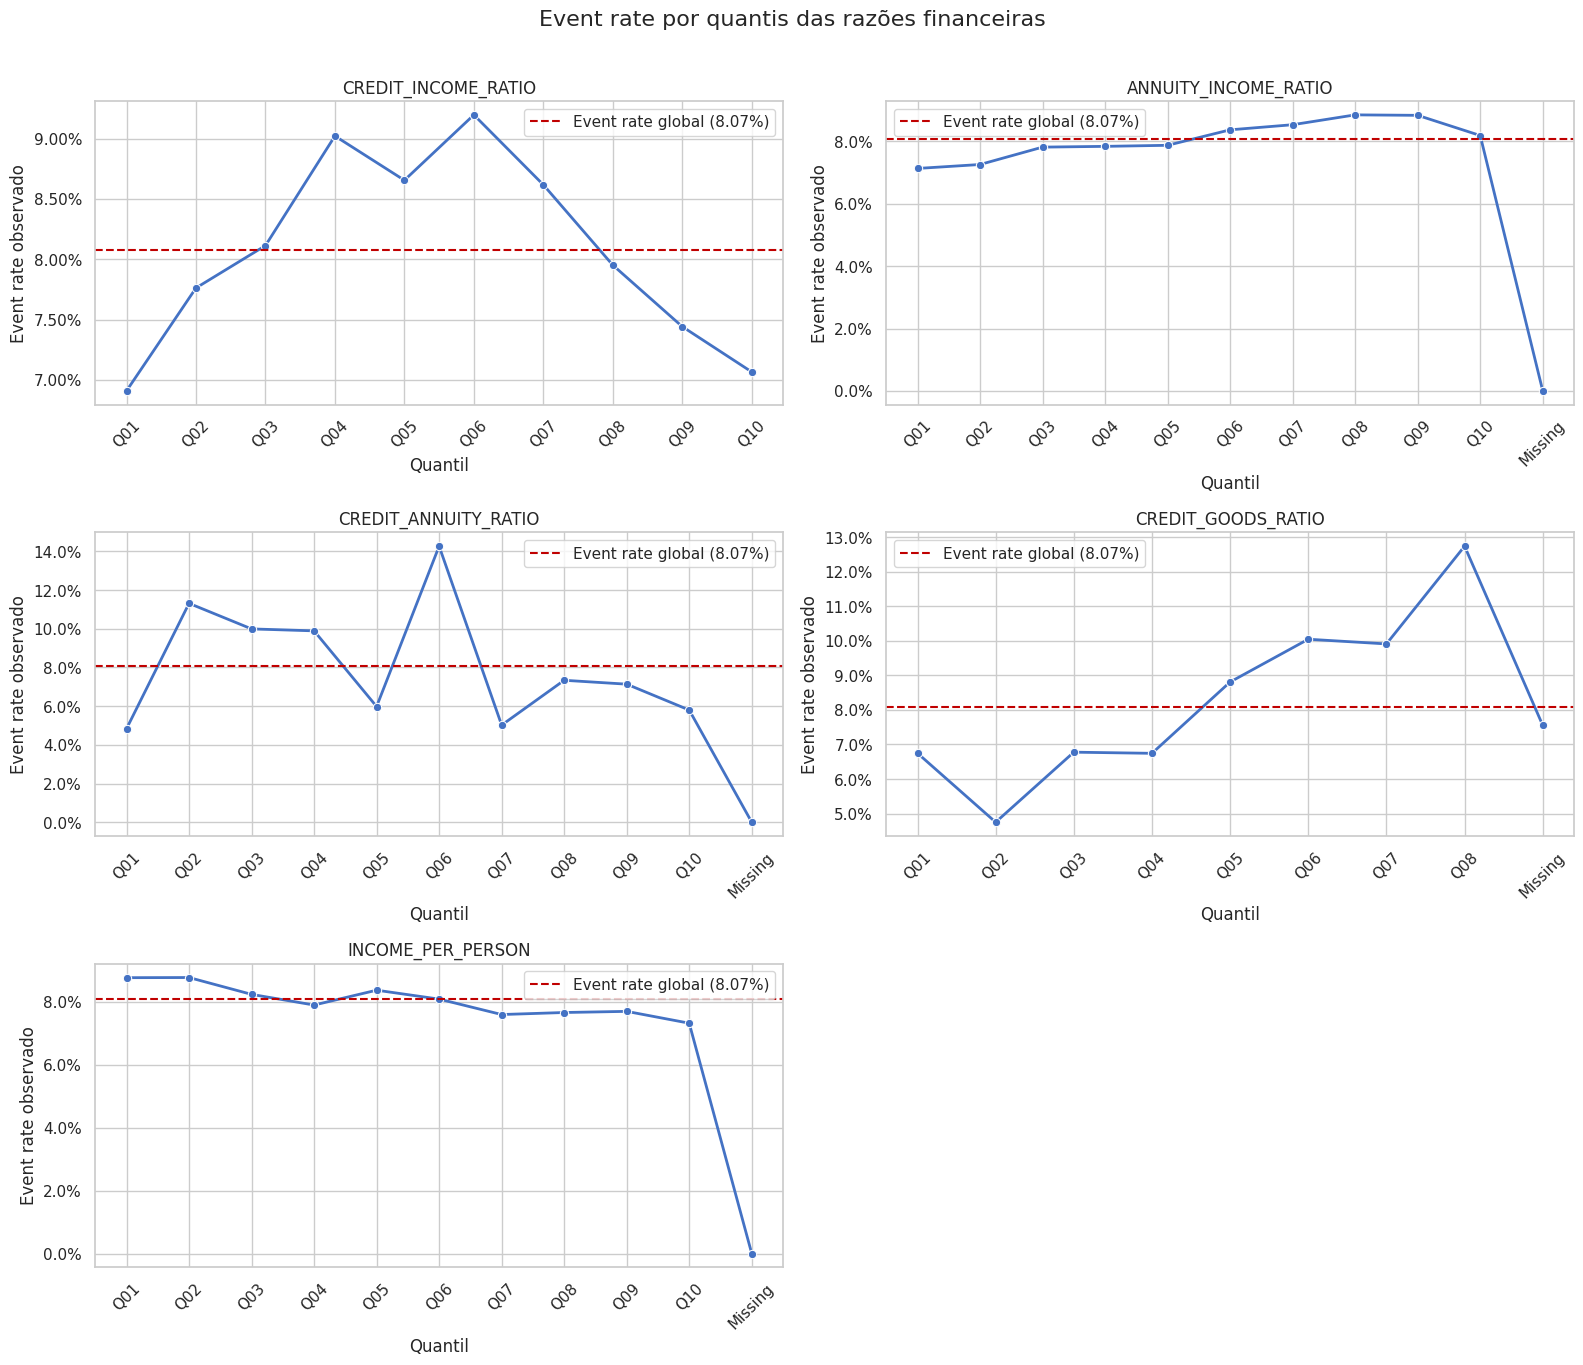

Figura salva em: /content/home-credit-default-risk/reports/figures/application_financial_ratio_event_rate.png


In [68]:
# Visualização dos resultados
n_columns = 2
n_rows = int(
    np.ceil(
        len(financial_ratio_columns)
        / n_columns
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(16, 4.5 * n_rows),
)

axes = np.atleast_1d(axes).flatten()

for axis, variable in zip(
    axes,
    financial_ratio_columns,
):
    plot_data = (
        financial_ratio_quantile_profiles
        .query("variable == @variable")
        .sort_values("bin_order")
    )

    sns.lineplot(
        data=plot_data,
        x="bin",
        y="event_rate",
        marker="o",
        linewidth=2,
        color="#4472C4",
        ax=axis,
    )

    axis.axhline(
        GLOBAL_EVENT_RATE,
        color="#C00000",
        linestyle="--",
        linewidth=1.5,
        label=(
            "Event rate global "
            f"({GLOBAL_EVENT_RATE:.2%})"
        ),
    )

    axis.set_title(variable)
    axis.set_xlabel("Quantil")
    axis.set_ylabel("Event rate observado")
    axis.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )
    axis.tick_params(
        axis="x",
        rotation=45,
    )
    axis.legend(loc="best")

for axis in axes[
    len(financial_ratio_columns):
]:
    axis.remove()

fig.suptitle(
    "Event rate por quantis das razões financeiras",
    fontsize=16,
    y=1.01,
)

plt.tight_layout()

financial_ratio_figure = (
    paths.figures
    / "application_financial_ratio_event_rate.png"
)

plt.savefig(
    financial_ratio_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    financial_ratio_figure,
)

### Interpretação das razões financeiras

As razões financeiras permitem comparar clientes em escalas relativas e podem apresentar maior poder discriminante que seus componentes isolados.

Entretanto, elas devem ser interpretadas com cautela:

- correlação com o `TARGET` não representa causalidade;
- denominadores pequenos podem produzir razões muito elevadas;
- renda declarada pode possuir erro de mensuração;
- a anuidade não representa todas as obrigações do cliente;
- renda por pessoa é apenas uma aproximação da capacidade financeira familiar;
- algumas razões podem carregar informação redundante em relação às variáveis originais.

A decisão de incluir essas features será tomada posteriormente, considerando desempenho, estabilidade, multicolinearidade, interpretabilidade e coerência de negócio.

In [69]:
# Persistência
financial_ratio_profile_output = (
    paths.tables
    / "application_financial_ratio_profile.csv"
)

financial_ratio_associations_output = (
    paths.tables
    / "application_financial_ratio_associations.csv"
)

financial_ratio_quantiles_output = (
    paths.tables
    / "application_financial_ratio_quantiles.csv"
)

financial_denominator_quality_output = (
    paths.tables
    / "application_financial_denominator_quality.csv"
)

financial_ratio_profile.to_csv(
    financial_ratio_profile_output,
    index=False,
)

financial_ratio_associations.to_csv(
    financial_ratio_associations_output,
    index=False,
)

financial_ratio_quantile_profiles.to_csv(
    financial_ratio_quantiles_output,
    index=False,
)

financial_denominator_quality.to_csv(
    financial_denominator_quality_output,
    index=False,
)

print("Resultados das razões financeiras salvos.")

Resultados das razões financeiras salvos.


## Comparação entre as populações de treino e teste

A tabela `application_test` representa a população sem `TARGET` disponibilizada para a competição Kaggle. Portanto, ela não será utilizada para avaliar discriminação, calibração ou qualquer outra métrica supervisionada.

Ainda assim, podemos comparar sua distribuição com a de `application_train` para identificar possíveis diferenças de composição entre as populações.

Será utilizado o `Population Stability Index` — PSI:

$$
\text{PSI}
=
\sum_{i=1}^{k}
\left(
p_{test,i} - p_{train,i}
\right)
\ln
\left(
\frac{p_{test,i}}{p_{train,i}}
\right)
$$

onde:

- $p_{train,i}$ é a proporção da população de treino na faixa $i$;
- $p_{test,i}$ é a proporção da população de teste na mesma faixa;
- $k$ é o número de faixas ou categorias.

Para as variáveis numéricas, as faixas serão definidas pelos quantis de `application_train` e aplicadas sem alteração em `application_test`. Para as variáveis categóricas, serão comparadas as proporções de cada categoria.

Os valores ausentes serão tratados como um grupo separado.

In [70]:
# Função para cálculo do PSI
PSI_EPSILON = 1e-6
PSI_N_QUANTILES = 10


def calculate_psi_from_groups(
    train_groups,
    test_groups,
    variable,
    variable_type,
    epsilon=PSI_EPSILON,
):
    """Calcula o PSI a partir de grupos comparáveis."""

    train_proportions = (
        train_groups
        .value_counts(normalize=True, dropna=False)
    )

    test_proportions = (
        test_groups
        .value_counts(normalize=True, dropna=False)
    )

    all_groups = (
        train_proportions.index
        .union(test_proportions.index)
    )

    train_proportions = (
        train_proportions
        .reindex(all_groups, fill_value=0)
        .astype(float)
    )

    test_proportions = (
        test_proportions
        .reindex(all_groups, fill_value=0)
        .astype(float)
    )

    adjusted_train = train_proportions.clip(
        lower=epsilon
    )

    adjusted_test = test_proportions.clip(
        lower=epsilon
    )

    psi_components = (
        adjusted_test - adjusted_train
    ) * np.log(
        adjusted_test / adjusted_train
    )

    detail = pd.DataFrame(
        {
            "variable": variable,
            "variable_type": variable_type,
            "group": all_groups.astype(str),
            "train_proportion": (
                train_proportions.to_numpy()
            ),
            "test_proportion": (
                test_proportions.to_numpy()
            ),
            "proportion_difference": (
                test_proportions.to_numpy()
                - train_proportions.to_numpy()
            ),
            "psi_component": (
                psi_components.to_numpy()
            ),
        }
    )

    total_psi = detail["psi_component"].sum()

    return total_psi, detail

In [71]:
# PSI para variáveis numéricas
def calculate_numeric_psi(
    train_series,
    test_series,
    variable,
    n_quantiles=PSI_N_QUANTILES,
):
    """Calcula PSI numérico com faixas do treino."""

    train_series = (
        train_series
        .replace([np.inf, -np.inf], np.nan)
    )

    test_series = (
        test_series
        .replace([np.inf, -np.inf], np.nan)
    )

    valid_train = train_series.dropna()

    if valid_train.nunique() < 2:
        train_groups = (
            train_series
            .notna()
            .map(
                {
                    True: "<OBSERVED>",
                    False: "<MISSING>",
                }
            )
        )

        test_groups = (
            test_series
            .notna()
            .map(
                {
                    True: "<OBSERVED>",
                    False: "<MISSING>",
                }
            )
        )

    else:
        quantile_values = (
            valid_train
            .quantile(
                np.linspace(
                    0,
                    1,
                    n_quantiles + 1,
                )
            )
            .drop_duplicates()
            .sort_values()
            .to_numpy()
        )

        internal_boundaries = (
            quantile_values[1:-1]
        )

        bin_edges = np.concatenate(
            [
                [-np.inf],
                internal_boundaries,
                [np.inf],
            ]
        )

        train_groups = (
            pd.cut(
                train_series,
                bins=bin_edges,
                include_lowest=True,
                duplicates="drop",
            )
            .astype("string")
            .fillna("<MISSING>")
        )

        test_groups = (
            pd.cut(
                test_series,
                bins=bin_edges,
                include_lowest=True,
                duplicates="drop",
            )
            .astype("string")
            .fillna("<MISSING>")
        )

    return calculate_psi_from_groups(
        train_groups=train_groups,
        test_groups=test_groups,
        variable=variable,
        variable_type="numeric",
    )

In [75]:
# PSI para variáveis categóricas
def calculate_categorical_psi(
    train_series,
    test_series,
    variable,
):
    """Calcula PSI para grupos categóricos."""

    train_groups = (
        train_series
        .astype("string")
        .fillna("<MISSING>")
    )

    test_groups = (
        test_series
        .astype("string")
        .fillna("<MISSING>")
    )

    return calculate_psi_from_groups(
        train_groups=train_groups,
        test_groups=test_groups,
        variable=variable,
        variable_type="categorical",
    )

In [73]:
train_drift_data = application_train.copy()
test_drift_data = application_test.copy()

for dataframe in [
    train_drift_data,
    test_drift_data,
]:
    dataframe.loc[
        dataframe["DAYS_EMPLOYED"].eq(
            SPECIAL_DAYS_EMPLOYED_VALUE
        ),
        "DAYS_EMPLOYED",
    ] = np.nan

In [74]:
# Calculo do PSI para as variáveis numéricas gerais
numeric_psi_summary = []
numeric_psi_details = []

for variable in general_numeric_columns:
    total_psi, detail = calculate_numeric_psi(
        train_series=train_drift_data[variable],
        test_series=test_drift_data[variable],
        variable=variable,
    )

    numeric_psi_summary.append(
        {
            "variable": variable,
            "variable_type": "numeric",
            "psi": total_psi,
        }
    )

    numeric_psi_details.append(detail)

numeric_psi_summary = pd.DataFrame(
    numeric_psi_summary
)

numeric_psi_details = pd.concat(
    numeric_psi_details,
    ignore_index=True,
)

In [76]:
# Calculo do PSI para as variáveis categóricas
categorical_psi_variables = list(
    dict.fromkeys(
        categorical_columns
        + binary_numeric_columns
        + low_cardinality_numeric_columns
    )
)

categorical_psi_summary = []
categorical_psi_details = []

for variable in categorical_psi_variables:
    total_psi, detail = (
        calculate_categorical_psi(
            train_series=train_drift_data[
                variable
            ],
            test_series=test_drift_data[
                variable
            ],
            variable=variable,
        )
    )

    categorical_psi_summary.append(
        {
            "variable": variable,
            "variable_type": "categorical",
            "psi": total_psi,
        }
    )

    categorical_psi_details.append(detail)

categorical_psi_summary = pd.DataFrame(
    categorical_psi_summary
)

categorical_psi_details = pd.concat(
    categorical_psi_details,
    ignore_index=True,
)

In [77]:
#Consolidação dos Resultados
population_psi_summary = pd.concat(
    [
        numeric_psi_summary,
        categorical_psi_summary,
    ],
    ignore_index=True,
)


def classify_psi(psi):
    if psi < 0.10:
        return "Baixa diferença"

    if psi < 0.25:
        return "Diferença moderada"

    return "Diferença relevante"


population_psi_summary[
    "psi_interpretation"
] = (
    population_psi_summary["psi"]
    .map(classify_psi)
)

population_psi_summary = (
    population_psi_summary
    .sort_values(
        "psi",
        ascending=False,
    )
    .reset_index(drop=True)
)

population_psi_details = pd.concat(
    [
        numeric_psi_details,
        categorical_psi_details,
    ],
    ignore_index=True,
)

display(
    population_psi_summary
    .head(30)
    .style.format(
        {
            "psi": "{:.4f}",
        }
    )
)

,variable,variable_type,psi,psi_interpretation
0,AMT_REQ_CREDIT_BUREAU_QRT,categorical,0.3115,Diferença relevante
1,NAME_CONTRACT_TYPE,categorical,0.2111,Diferença moderada
2,AMT_REQ_CREDIT_BUREAU_MON,numeric,0.1398,Diferença moderada
3,FLAG_EMAIL,categorical,0.1242,Diferença moderada
4,FLAG_DOCUMENT_16,categorical,0.0915,Baixa diferença
5,AMT_GOODS_PRICE,numeric,0.0891,Baixa diferença
6,EXT_SOURCE_1,numeric,0.0846,Baixa diferença
7,AMT_CREDIT,numeric,0.0692,Baixa diferença
8,DAYS_ID_PUBLISH,numeric,0.0671,Baixa diferença
9,AMT_REQ_CREDIT_BUREAU_WEEK,categorical,0.0653,Baixa diferença


### Interpretação do PSI

Como referência exploratória, serão utilizadas as seguintes faixas:

| PSI | Interpretação |
|---:|:---|
| Menor que `0,10` | Baixa diferença entre as populações |
| De `0,10` até `0,25` | Diferença moderada |
| Maior ou igual a `0,25` | Diferença relevante |

Esses limites são regras práticas de mercado e não testes estatísticos universais. A interpretação também deve considerar:

- tamanho das amostras;
- quantidade e definição das faixas;
- concentração das categorias;
- qualidade e disponibilidade dos dados;
- relevância da variável para o modelo;
- contexto de negócio.

Um PSI elevado não demonstra, isoladamente, que uma variável deve ser removida. Ele indica que sua distribuição merece investigação e que a relação aprendida na população de treino pode não se transferir integralmente para outra população.

Também é importante observar que `application_train` e `application_test` são divisões fornecidas pela competição. Como não existe uma data de referência confiável para construir uma separação temporal, essa comparação não deve ser apresentada como uma validação `Out-of-Time`.

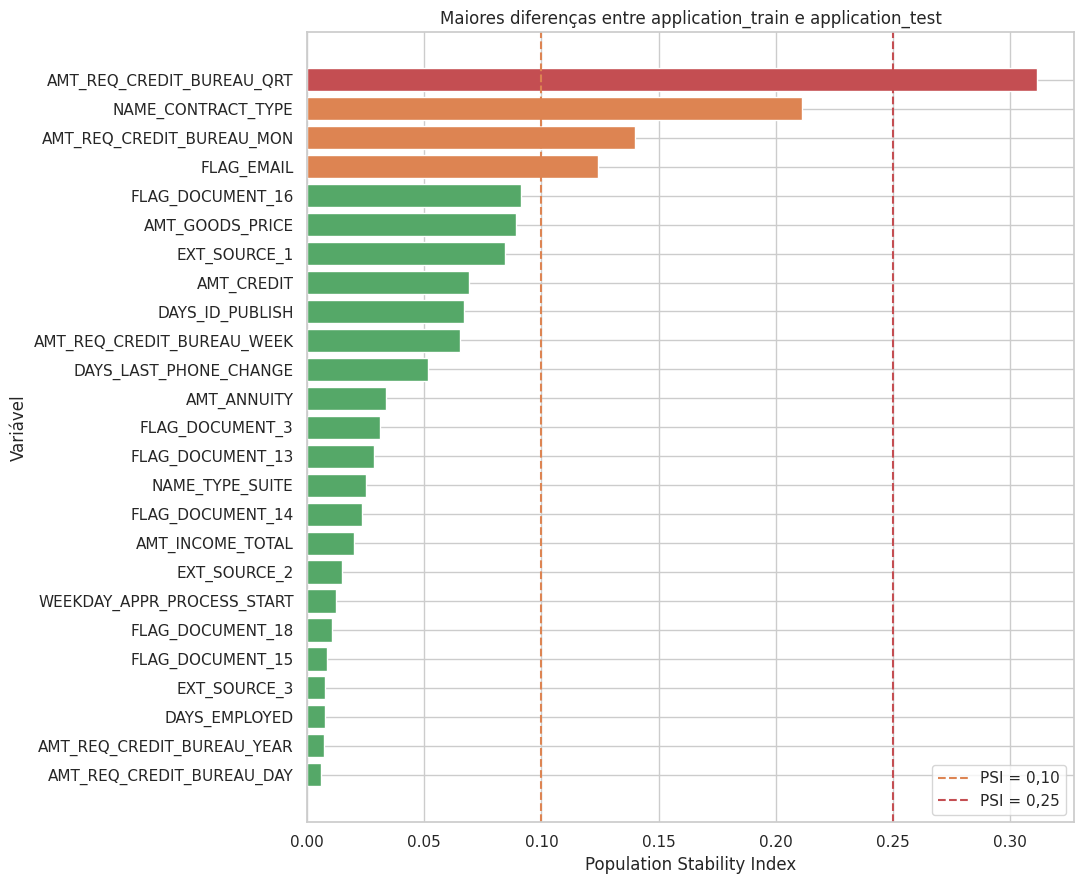

Figura salva em: /content/home-credit-default-risk/reports/figures/application_train_test_psi.png


In [78]:
#Visualização das Diferenças
N_PSI_VARIABLES_TO_PLOT = 25

top_psi_variables = (
    population_psi_summary
    .head(N_PSI_VARIABLES_TO_PLOT)
    .sort_values("psi")
)

psi_colors = top_psi_variables[
    "psi_interpretation"
].map(
    {
        "Baixa diferença": "#55A868",
        "Diferença moderada": "#DD8452",
        "Diferença relevante": "#C44E52",
    }
)

fig, axis = plt.subplots(
    figsize=(11, 9)
)

axis.barh(
    top_psi_variables["variable"],
    top_psi_variables["psi"],
    color=psi_colors,
)

axis.axvline(
    0.10,
    color="#DD8452",
    linestyle="--",
    linewidth=1.5,
    label="PSI = 0,10",
)

axis.axvline(
    0.25,
    color="#C44E52",
    linestyle="--",
    linewidth=1.5,
    label="PSI = 0,25",
)

axis.set_title(
    "Maiores diferenças entre application_train "
    "e application_test"
)
axis.set_xlabel("Population Stability Index")
axis.set_ylabel("Variável")
axis.legend()

plt.tight_layout()

population_psi_figure = (
    paths.figures
    / "application_train_test_psi.png"
)

plt.savefig(
    population_psi_figure,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em:",
    population_psi_figure,
)

In [79]:
# Identificação dos grupos que mais contribuem para o PSI
top_psi_variable_names = (
    population_psi_summary
    .head(10)["variable"]
    .tolist()
)

top_psi_components = (
    population_psi_details
    .query(
        "variable in @top_psi_variable_names"
    )
    .sort_values(
        ["variable", "psi_component"],
        ascending=[True, False],
    )
    .groupby(
        "variable",
        group_keys=False,
    )
    .head(5)
)

display(
    top_psi_components.style.format(
        {
            "train_proportion": "{:.2%}",
            "test_proportion": "{:.2%}",
            "proportion_difference": "{:+.2%}",
            "psi_component": "{:.4f}",
        }
    )
)

,variable,variable_type,group,train_proportion,test_proportion,proportion_difference,psi_component
489,AMT_CREDIT,numeric,"(1133748.0, inf]",9.95%,5.75%,-4.19%,0.0230
497,AMT_CREDIT,numeric,"(900000.0, 1133748.0]",9.21%,5.81%,-3.40%,0.0156
492,AMT_CREDIT,numeric,"(306306.0, 432000.0]",9.99%,13.31%,+3.32%,0.0096
493,AMT_CREDIT,numeric,"(432000.0, 513531.0]",10.02%,12.71%,+2.68%,0.0064
496,AMT_CREDIT,numeric,"(755190.0, 900000.0]",9.74%,7.69%,-2.05%,0.0048
257,AMT_GOODS_PRICE,numeric,"(1093500.0, inf]",9.98%,5.68%,-4.30%,0.0242
264,AMT_GOODS_PRICE,numeric,"(675000.0, 814500.0]",6.16%,3.18%,-2.98%,0.0197
260,AMT_GOODS_PRICE,numeric,"(270000.0, 373500.0]",7.64%,11.75%,+4.11%,0.0177
265,AMT_GOODS_PRICE,numeric,"(814500.0, 1093500.0]",10.00%,7.08%,-2.92%,0.0101
256,AMT_GOODS_PRICE,numeric,"(-inf, 180000.0]",12.84%,16.17%,+3.33%,0.0077


In [80]:
#Persistência
population_psi_summary_output = (
    paths.tables
    / "application_train_test_psi_summary.csv"
)

population_psi_details_output = (
    paths.tables
    / "application_train_test_psi_details.csv"
)

population_psi_summary.to_csv(
    population_psi_summary_output,
    index=False,
)

population_psi_details.to_csv(
    population_psi_details_output,
    index=False,
)

print(
    "Resumo do PSI salvo em:",
    population_psi_summary_output,
)

print(
    "Detalhamento do PSI salvo em:",
    population_psi_details_output,
)

Resumo do PSI salvo em: /content/home-credit-default-risk/reports/tables/application_train_test_psi_summary.csv
Detalhamento do PSI salvo em: /content/home-credit-default-risk/reports/tables/application_train_test_psi_details.csv


## Consolidação dos achados

Esta seção consolida os principais resultados da análise exploratória e registra as decisões que orientarão as próximas etapas do projeto.

As conclusões apresentadas não representam ainda uma seleção definitiva de features. Elas identificam:

- problemas de qualidade que exigirão tratamento;
- variáveis com associação exploratória com o `TARGET`;
- grupos de features potencialmente redundantes;
- diferenças entre as populações de treino e teste;
- oportunidades de feature engineering;
- cuidados necessários para evitar `data leakage`.

A seleção definitiva será realizada posteriormente, utilizando somente a amostra de treino e considerando desempenho, estabilidade, interpretabilidade e coerência de negócio.

In [87]:
# Resumo Qualitativo
HIGH_MISSING_THRESHOLD = 0.40
MODERATE_PSI_THRESHOLD = 0.10
RELEVANT_PSI_THRESHOLD = 0.25

application_feature_columns = [
    column
    for column in application_train.columns
    if column not in [
        "TARGET",
        "SK_ID_CURR",
    ]
]

n_high_missing_variables = (
    application_train[
        application_feature_columns
    ]
    .isna()
    .mean()
    .ge(HIGH_MISSING_THRESHOLD)
    .sum()
)

eda_summary = pd.DataFrame(
    [
        {
            "indicator": (
                "Registros em application_train"
            ),
            "value": len(application_train),
            "value_type": "count",
        },
        {
            "indicator": (
                "Registros em application_test"
            ),
            "value": len(application_test),
            "value_type": "count",
        },
        {
            "indicator": (
                "Features de application_train"
            ),
            "value": (
                application_train.shape[1] - 1
            ),
            "value_type": "count",
        },
        {
            "indicator": "Event rate global",
            "value": GLOBAL_EVENT_RATE,
            "value_type": "percentage",
        },
        {
            "indicator": (
                "Variáveis com pelo menos "
                "40% de missing"
            ),
            "value": n_high_missing_variables,
            "value_type": "count",
        },
        {
            "indicator": (
                "Pares numéricos com "
                "|correlação| >= 0,80"
            ),
            "value": len(
                high_correlation_pairs
            ),
            "value_type": "count",
        },
        {
            "indicator": (
                "Variáveis com PSI >= 0,10"
            ),
            "value": (
                population_psi_summary["psi"]
                .ge(MODERATE_PSI_THRESHOLD)
                .sum()
            ),
            "value_type": "count",
        },
        {
            "indicator": (
                "Variáveis com PSI >= 0,25"
            ),
            "value": (
                population_psi_summary["psi"]
                .ge(RELEVANT_PSI_THRESHOLD)
                .sum()
            ),
            "value_type": "count",
        },
        {
            "indicator": (
                "Registros com "
                "DAYS_EMPLOYED = 365243"
            ),
            "value": (
                application_train[
                    "DAYS_EMPLOYED"
                ]
                .eq(
                    SPECIAL_DAYS_EMPLOYED_VALUE
                )
                .sum()
            ),
            "value_type": "count",
        },
        {
            "indicator": (
                "Features financeiras candidatas"
            ),
            "value": len(
                financial_ratio_columns
            ),
            "value_type": "count",
        },
    ]
)

eda_summary["formatted_value"] = (
    eda_summary.apply(
        lambda row: (
            f"{row['value']:.2%}"
            if row["value_type"] == "percentage"
            else f"{int(row['value']):,}"
            .replace(",", ".")
        ),
        axis=1,
    )
)

display(
    eda_summary[
        [
            "indicator",
            "formatted_value",
        ]
    ]
)

,indicator,formatted_value
0,Registros em application_train,307.511
1,Registros em application_test,48.744
2,Features de application_train,121
3,Event rate global,8.07%
4,Variáveis com pelo menos 40% de missing,49
5,"Pares numéricos com |correlação| >= 0,80",100
6,"Variáveis com PSI >= 0,10",4
7,"Variáveis com PSI >= 0,25",1
8,Registros com DAYS_EMPLOYED = 365243,55.374
9,Features financeiras candidatas,5


In [88]:
# Formatação do Event Rate
eda_summary_display = eda_summary.copy()

eda_summary_display["formatted_value"] = (
    eda_summary_display.apply(
        lambda row: (
            f"{row['value']:.2%}"
            if row["indicator"]
            == "Event rate global"
            else f"{int(row['value']):,}"
            .replace(",", ".")
        ),
        axis=1,
    )
)

display(
    eda_summary_display[
        ["indicator", "formatted_value"]
    ]
)

,indicator,formatted_value
0,Registros em application_train,307.511
1,Registros em application_test,48.744
2,Features de application_train,121
3,Event rate global,8.07%
4,Variáveis com pelo menos 40% de missing,49
5,"Pares numéricos com |correlação| >= 0,80",100
6,"Variáveis com PSI >= 0,10",4
7,"Variáveis com PSI >= 0,25",1
8,Registros com DAYS_EMPLOYED = 365243,55.374
9,Features financeiras candidatas,5


In [90]:
# Variáveis com alta proporção de missing
high_missing_variables = (
    application_train[
        application_feature_columns
    ]
    .isna()
    .agg(
        ["sum", "mean"]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "variable",
            "sum": "n_missing",
            "mean": "missing_rate",
        }
    )
)

high_missing_variables = (
    high_missing_variables
    .query(
        "missing_rate >= @HIGH_MISSING_THRESHOLD"
    )
    .sort_values(
        "missing_rate",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    high_missing_variables.style.format(
        {
            "n_missing": "{:,.0f}",
            "missing_rate": "{:.2%}",
        }
    )
)

,variable,n_missing,missing_rate
0,COMMONAREA_AVG,"214,865",69.87%
1,COMMONAREA_MEDI,"214,865",69.87%
2,COMMONAREA_MODE,"214,865",69.87%
3,NONLIVINGAPARTMENTS_AVG,"213,514",69.43%
4,NONLIVINGAPARTMENTS_MEDI,"213,514",69.43%
5,NONLIVINGAPARTMENTS_MODE,"213,514",69.43%
6,FONDKAPREMONT_MODE,"210,295",68.39%
7,LIVINGAPARTMENTS_MEDI,"210,199",68.35%
8,LIVINGAPARTMENTS_AVG,"210,199",68.35%
9,LIVINGAPARTMENTS_MODE,"210,199",68.35%


Uma proporção elevada de valores ausentes não determina automaticamente a exclusão de uma variável.

Antes de qualquer decisão, será necessário avaliar:

- associação do próprio missing com o `TARGET`;
- disponibilidade da informação no momento da aplicação;
- estabilidade entre as populações;
- contribuição preditiva;
- possibilidade de imputação;
- significado de negócio.

O tratamento deverá preservar, quando relevante, o sinal associado à indisponibilidade da informação.

In [91]:
# Features numéricas mais associadas ao TARGET
top_numeric_target_findings = (
    numeric_target_associations
    .head(15)
    [
        [
            "variable",
            "classification",
            "missing_rate",
            "spearman_correlation",
            "absolute_spearman_correlation",
        ]
    ]
)

display(
    top_numeric_target_findings.style.format(
        {
            "missing_rate": "{:.2%}",
            "spearman_correlation": "{:+.4f}",
            "absolute_spearman_correlation": "{:.4f}",
        }
    )
)

,variable,classification,missing_rate,spearman_correlation,absolute_spearman_correlation
0,EXT_SOURCE_3,general_numeric,19.83%,-0.1663,0.1663
1,EXT_SOURCE_1,general_numeric,56.38%,-0.1511,0.1511
2,EXT_SOURCE_2,general_numeric,0.21%,-0.1473,0.1473
3,DAYS_EMPLOYED,general_numeric,18.01%,+0.0803,0.0803
4,DAYS_BIRTH,general_numeric,0.00%,+0.0783,0.0783
5,REGION_RATING_CLIENT_W_CITY,low_cardinality,0.00%,+0.0609,0.0609
6,REGION_RATING_CLIENT,low_cardinality,0.00%,+0.0589,0.0589
7,DAYS_LAST_PHONE_CHANGE,general_numeric,0.00%,+0.0537,0.0537
8,OWN_CAR_AGE,general_numeric,65.99%,+0.0529,0.0529
9,DAYS_ID_PUBLISH,general_numeric,0.00%,+0.0525,0.0525


In [92]:
# Features categóricas com maior separação observada
top_categorical_target_findings = (
    categorical_separation_summary
    .head(15)
    .copy()
)

display(
    top_categorical_target_findings.style.format(
        {
            "min_event_rate": "{:.2%}",
            "max_event_rate": "{:.2%}",
            "event_rate_range": "{:.2%}",
        }
    )
)

,variable,n_supported_categories,min_event_rate,max_event_rate,event_rate_range
12,OCCUPATION_TYPE,14,4.83%,17.15%,12.32%
13,ORGANIZATION_TYPE,29,4.86%,11.71%,6.84%
9,NAME_HOUSING_TYPE,5,6.57%,12.31%,5.74%
7,NAME_EDUCATION_TYPE,4,5.36%,10.93%,5.57%
14,WALLSMATERIAL_MODE,8,4.72%,9.70%,4.98%
10,NAME_INCOME_TYPE,4,5.39%,9.59%,4.20%
8,NAME_FAMILY_STATUS,5,5.82%,9.94%,4.12%
0,CODE_GENDER,2,7.00%,10.14%,3.14%
6,NAME_CONTRACT_TYPE,2,5.48%,8.35%,2.87%
4,FONDKAPREMONT_MODE,5,5.82%,8.62%,2.80%


In [93]:
# Maiores diferenças entre treino e teste
top_population_differences = (
    population_psi_summary
    .head(15)
    .copy()
)

display(
    top_population_differences.style.format(
        {
            "psi": "{:.4f}",
        }
    )
)

,variable,variable_type,psi,psi_interpretation
0,AMT_REQ_CREDIT_BUREAU_QRT,categorical,0.3115,Diferença relevante
1,NAME_CONTRACT_TYPE,categorical,0.2111,Diferença moderada
2,AMT_REQ_CREDIT_BUREAU_MON,numeric,0.1398,Diferença moderada
3,FLAG_EMAIL,categorical,0.1242,Diferença moderada
4,FLAG_DOCUMENT_16,categorical,0.0915,Baixa diferença
5,AMT_GOODS_PRICE,numeric,0.0891,Baixa diferença
6,EXT_SOURCE_1,numeric,0.0846,Baixa diferença
7,AMT_CREDIT,numeric,0.0692,Baixa diferença
8,DAYS_ID_PUBLISH,numeric,0.0671,Baixa diferença
9,AMT_REQ_CREDIT_BUREAU_WEEK,categorical,0.0653,Baixa diferença


## Registro das decisões metodológicas

As decisões abaixo serão utilizadas como requisitos para os próximos notebooks. Elas poderão ser revisadas caso as etapas de modelagem ou validação forneçam novas evidências.

In [94]:
# tabela de decisões
eda_decisions = pd.DataFrame(
    [
        {
            "topic": "Identificador",
            "finding": (
                "SK_ID_CURR identifica cada aplicação."
            ),
            "decision": (
                "Preservar como chave e excluir das "
                "features dos modelos."
            ),
            "implementation_stage": (
                "Preparação dos dados"
            ),
        },
        {
            "topic": "DAYS_EMPLOYED",
            "finding": (
                "O valor 365243 representa um código "
                "especial, e não tempo de emprego real."
            ),
            "decision": (
                "Substituir 365243 por NaN e criar uma "
                "flag indicadora."
            ),
            "implementation_stage": (
                "Feature engineering"
            ),
        },
        {
            "topic": "Variáveis temporais",
            "finding": (
                "As variáveis DAYS_* são intervalos "
                "relativos à data da aplicação."
            ),
            "decision": (
                "Converter variáveis selecionadas para "
                "unidades interpretáveis, preservando "
                "as informações originais quando útil."
            ),
            "implementation_stage": (
                "Feature engineering"
            ),
        },
        {
            "topic": "Missing",
            "finding": (
                "Existem variáveis com alta proporção "
                "de valores ausentes e missing "
                "associado ao TARGET."
            ),
            "decision": (
                "Ajustar imputação somente no treino e "
                "avaliar flags de missing."
            ),
            "implementation_stage": (
                "Preprocessing"
            ),
        },
        {
            "topic": "Categorias raras",
            "finding": (
                "Algumas variáveis possuem categorias "
                "de baixo suporte."
            ),
            "decision": (
                "Definir agrupamento com base apenas no "
                "treino e mapear categorias desconhecidas."
            ),
            "implementation_stage": (
                "Preprocessing"
            ),
        },
        {
            "topic": "Valores especiais categóricos",
            "finding": (
                "Foram encontrados valores como XNA, "
                "XAP e Unknown."
            ),
            "decision": (
                "Não converter automaticamente em "
                "missing; avaliar o significado de cada "
                "variável."
            ),
            "implementation_stage": (
                "Preprocessing"
            ),
        },
        {
            "topic": "Valores extremos",
            "finding": (
                "Variáveis financeiras apresentam "
                "assimetria e caudas longas."
            ),
            "decision": (
                "Preservar inicialmente e comparar "
                "transformação, binning ou cap ajustado "
                "somente no treino."
            ),
            "implementation_stage": (
                "Modelagem"
            ),
        },
        {
            "topic": "Razões financeiras",
            "finding": (
                "Foram criadas relações entre renda, "
                "crédito, anuidade, bem e tamanho "
                "familiar."
            ),
            "decision": (
                "Implementar como features candidatas "
                "com divisão segura e flags quando "
                "necessário."
            ),
            "implementation_stage": (
                "Feature engineering"
            ),
        },
        {
            "topic": "Multicolinearidade",
            "finding": (
                "Existem grupos de features altamente "
                "correlacionadas."
            ),
            "decision": (
                "Avaliar redundância, estabilidade dos "
                "coeficientes e VIF na regressão "
                "logística."
            ),
            "implementation_stage": (
                "Seleção de features"
            ),
        },
        {
            "topic": "Population drift",
            "finding": (
                "O PSI identificou diferenças de "
                "distribuição entre train e test."
            ),
            "decision": (
                "Investigar as variáveis com PSI "
                "moderado ou relevante antes da "
                "modelagem final."
            ),
            "implementation_stage": (
                "Validação"
            ),
        },
        {
            "topic": "application_test",
            "finding": (
                "A tabela não possui TARGET."
            ),
            "decision": (
                "Não utilizar para métricas "
                "supervisionadas nem como teste final "
                "do modelo."
            ),
            "implementation_stage": (
                "Divisão das amostras"
            ),
        },
        {
            "topic": "Validação",
            "finding": (
                "Não existe uma data de aplicação "
                "confiável para separação temporal."
            ),
            "decision": (
                "Criar train, validation e test "
                "estratificados a partir de "
                "application_train e declarar que não "
                "se trata de Out-of-Time."
            ),
            "implementation_stage": (
                "Divisão das amostras"
            ),
        },
        {
            "topic": "Data leakage",
            "finding": (
                "Transformações e seleção podem usar "
                "informações da distribuição dos dados."
            ),
            "decision": (
                "Ajustar imputação, binning, encoding, "
                "cap e seleção exclusivamente no treino."
            ),
            "implementation_stage": (
                "Todo o pipeline"
            ),
        },
    ]
)

display(eda_decisions)

,topic,finding,decision,implementation_stage
0,Identificador,SK_ID_CURR identifica cada aplicação.,Preservar como chave e excluir das features dos modelos.,Preparação dos dados
1,DAYS_EMPLOYED,"O valor 365243 representa um código especial, e não tempo de emprego real.",Substituir 365243 por NaN e criar uma flag indicadora.,Feature engineering
2,Variáveis temporais,As variáveis DAYS_* são intervalos relativos à data da aplicação.,"Converter variáveis selecionadas para unidades interpretáveis, preservando as informações originais quando útil.",Feature engineering
3,Missing,Existem variáveis com alta proporção de valores ausentes e missing associado ao TARGET.,Ajustar imputação somente no treino e avaliar flags de missing.,Preprocessing
4,Categorias raras,Algumas variáveis possuem categorias de baixo suporte.,Definir agrupamento com base apenas no treino e mapear categorias desconhecidas.,Preprocessing
5,Valores especiais categóricos,"Foram encontrados valores como XNA, XAP e Unknown.",Não converter automaticamente em missing; avaliar o significado de cada variável.,Preprocessing
6,Valores extremos,Variáveis financeiras apresentam assimetria e caudas longas.,"Preservar inicialmente e comparar transformação, binning ou cap ajustado somente no treino.",Modelagem
7,Razões financeiras,"Foram criadas relações entre renda, crédito, anuidade, bem e tamanho familiar.",Implementar como features candidatas com divisão segura e flags quando necessário.,Feature engineering
8,Multicolinearidade,Existem grupos de features altamente correlacionadas.,"Avaliar redundância, estabilidade dos coeficientes e VIF na regressão logística.",Seleção de features
9,Population drift,O PSI identificou diferenças de distribuição entre train e test.,Investigar as variáveis com PSI moderado ou relevante antes da modelagem final.,Validação


In [95]:
# Persistência
import json

eda_summary_output = (
    paths.tables
    / "application_eda_summary.csv"
)

eda_decisions_output = (
    paths.tables
    / "application_eda_decisions.csv"
)

high_missing_output = (
    paths.tables
    / "application_high_missing_variables.csv"
)

eda_summary.to_csv(
    eda_summary_output,
    index=False,
)

eda_decisions.to_csv(
    eda_decisions_output,
    index=False,
)

high_missing_variables.to_csv(
    high_missing_output,
    index=False,
)

print(f"Resumo salvo em: {eda_summary_output}")
print(f"Decisões salvas em: {eda_decisions_output}")
print(
    "Variáveis com alto missing salvas em:",
    high_missing_output,
)




eda_metadata = {
    "dataset": "Home Credit Default Risk",
    "analysis_table": "application_train.csv",
    "target": "TARGET",
    "identifier": "SK_ID_CURR",
    "global_event_rate": float(
        GLOBAL_EVENT_RATE
    ),
    "special_values": {
        "DAYS_EMPLOYED": {
            "value": int(
                SPECIAL_DAYS_EMPLOYED_VALUE
            ),
            "planned_treatment": (
                "Replace with NaN and create flag"
            ),
        }
    },
    "validation_strategy": {
        "source": "application_train",
        "split": (
            "Stratified train-validation-test"
        ),
        "out_of_time": False,
        "reason": (
            "Reliable application reference date "
            "is not available"
        ),
    },
    "application_test_usage": (
        "Population comparison and Kaggle scoring only"
    ),
    "candidate_financial_features": (
        financial_ratio_columns
    ),
    "psi_thresholds": {
        "moderate": MODERATE_PSI_THRESHOLD,
        "relevant": RELEVANT_PSI_THRESHOLD,
    },
    "decisions": (
        eda_decisions.to_dict(
            orient="records"
        )
    ),
}

eda_metadata_output = (
    paths.metadata
    / "application_eda_metadata.json"
)

with open(
    eda_metadata_output,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        eda_metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Metadados da EDA salvos em:",
    eda_metadata_output,
)

Resumo salvo em: /content/home-credit-default-risk/reports/tables/application_eda_summary.csv
Decisões salvas em: /content/home-credit-default-risk/reports/tables/application_eda_decisions.csv
Variáveis com alto missing salvas em: /content/home-credit-default-risk/reports/tables/application_high_missing_variables.csv
Metadados da EDA salvos em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/application_eda_metadata.json


## Conclusão

A análise exploratória mostrou que a tabela de aplicações contém informações cadastrais, financeiras, familiares, externas e relacionadas ao imóvel com potencial para modelagem de risco de crédito.

Os principais pontos identificados foram:

- desbalanceamento do `TARGET`, que deverá ser considerado na avaliação dos modelos;
- presença relevante de valores ausentes;
- missing potencialmente informativo em algumas features;
- código especial em `DAYS_EMPLOYED`;
- distribuições financeiras assimétricas e com caudas longas;
- associação bivariada entre diversas features e o `TARGET`;
- relações não lineares observadas por meio dos quantis;
- grupos de variáveis altamente correlacionadas;
- razões financeiras candidatas com interpretação de negócio;
- diferenças de distribuição entre `application_train` e `application_test`.

Nenhuma variável foi removida definitivamente nesta etapa. As análises realizadas servem como evidência para a construção do pipeline de preparação, e não como seleção final de features.

Como `application_test` não possui `TARGET`, a avaliação supervisionada será realizada por meio de uma divisão estratificada de `application_train` em amostras de treino, validação e teste. Essa estratégia não será apresentada como validação `Out-of-Time`, pois a base não disponibiliza uma data de referência confiável para essa finalidade.

A próxima etapa do projeto será preparar a base de modelagem, implementar as features candidatas de forma reprodutível e criar as divisões que serão utilizadas no desenvolvimento e na avaliação dos modelos.

<!--  -->